# Baseline

In [2]:
import os
import json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

import open_clip
from transformers import AutoProcessor, CLIPModel

warnings.filterwarnings("ignore")

# -----------------------------
# Paths
# -----------------------------
STYLE_DATA_DIR = os.path.join("..", "..", "1_data", "Style_dataset")

TRAIN_CSV = os.path.join(STYLE_DATA_DIR, "train.csv")
VAL_CSV   = os.path.join(STYLE_DATA_DIR, "val.csv")
TEST_CSV  = os.path.join(STYLE_DATA_DIR, "test.csv")

TRAIN_IMG_DIR = os.path.join(STYLE_DATA_DIR, "images", "train")
VAL_IMG_DIR   = os.path.join(STYLE_DATA_DIR, "images", "val")
TEST_IMG_DIR  = os.path.join(STYLE_DATA_DIR, "images", "test")

BASELINE_DIR = Path("baseline_result")
CKPT_DIR     = os.path.join(BASELINE_DIR, "checkpoints")
PRED_DIR     = os.path.join(BASELINE_DIR, "predictions")
METRIC_DIR   = os.path.join(BASELINE_DIR, "metrics")
FIG_DIR      = os.path.join(BASELINE_DIR, "figures")

for p in [BASELINE_DIR, CKPT_DIR, PRED_DIR, METRIC_DIR, FIG_DIR]:
    os.makedirs(p, exist_ok=True)

print("Baseline result folders are ready.")
print(BASELINE_DIR)

c:\Users\Sandy\.conda\envs\Thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Baseline result folders are ready.
baseline_result


## Config

In [3]:
# -----------------------------
# General config
# -----------------------------
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# -----------------------------
# OpenFashionCLIP config
# Replace these with your actual checkpoint if needed
# -----------------------------
OPENFASHIONCLIP_MODEL_NAME = "ViT-B-32"
OPENFASHIONCLIP_PRETRAINED = "laion2b_s34b_b79k"

# -----------------------------
# FashionCLIP config
# If your environment uses a different HF model id, replace it here
# -----------------------------
FASHIONCLIP_MODEL_ID = "patrickjohncyh/fashion-clip"

Device: cuda


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Read CSVs

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df["id"] = train_df["id"].astype(str)
val_df["id"]   = val_df["id"].astype(str)
test_df["id"]  = test_df["id"].astype(str)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain distribution:")
print(train_df["style"].value_counts())

# Build label mapping from train set
style_names = sorted(train_df["style"].unique())
label2idx = {label: idx for idx, label in enumerate(style_names)}
idx2label = {idx: label for label, idx in label2idx.items()}

num_classes = len(style_names)
print("\nNumber of classes:", num_classes)
print("Labels:", style_names)

with open(os.path.join(METRIC_DIR, "label_mapping.json"), "w") as f:
    json.dump(
        {
            "label2idx": label2idx,
            "idx2label": {str(k): v for k, v in idx2label.items()}
        },
        f,
        indent=2
    )

Train shape: (11775, 2)
Val shape  : (2523, 2)
Test shape : (2537, 2)

Train distribution:
style
street            790
gal               751
mode              736
conservative      732
girlish           729
retro             705
natural           704
Casual            700
Ethnic            700
Formal            700
Sports            700
kireime-casual    691
lolita            683
rock              681
dressy            620
fairy             614
feminine          539
Name: count, dtype: int64

Number of classes: 17
Labels: ['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']


In [6]:
print("Style label to index mapping:")

for style, idx in label2idx.items():
    print(f"{style} -> {idx}")

Style label to index mapping:
Casual -> 0
Ethnic -> 1
Formal -> 2
Sports -> 3
conservative -> 4
dressy -> 5
fairy -> 6
feminine -> 7
gal -> 8
girlish -> 9
kireime-casual -> 10
lolita -> 11
mode -> 12
natural -> 13
retro -> 14
rock -> 15
street -> 16


## Image lookup

In [18]:
VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

def build_image_lookup(image_dir):
    """
    Build a dictionary: image_id -> full_path
    """
    lookup = {}
    for fname in os.listdir(image_dir):
        fpath = os.path.join(image_dir, fname)
        if not os.path.isfile(fpath):
            continue

        stem, ext = os.path.splitext(fname)
        if ext.lower() in VALID_EXTS:
            lookup[stem] = fpath
    return lookup

train_lookup = build_image_lookup(TRAIN_IMG_DIR)
val_lookup   = build_image_lookup(VAL_IMG_DIR)
test_lookup  = build_image_lookup(TEST_IMG_DIR)

print("Train images:", len(train_lookup))
print("Val images  :", len(val_lookup))
print("Test images :", len(test_lookup))

Train images: 11775
Val images  : 2523
Test images : 2537


## Dataset Class

In [19]:
# Generic dataset for ResNet / OpenCLIP
class StyleImageDataset(Dataset):
    def __init__(self, df, image_lookup, label2idx, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.image_lookup = image_lookup
        self.label2idx = label2idx
        self.transform = transform

        # Keep only rows with existing images
        keep_rows = []
        missing = 0
        for _, row in self.df.iterrows():
            image_id = str(row["id"])
            if image_id in self.image_lookup:
                keep_rows.append(row)
            else:
                missing += 1

        self.df = pd.DataFrame(keep_rows).reset_index(drop=True)

        print(f"Dataset initialized: {len(self.df)} samples, missing images skipped: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["id"])
        label_name = row["style"]
        label = self.label2idx[label_name]

        image = Image.open(self.image_lookup[image_id]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "id": image_id,
            "image": image,
            "label": label,
            "label_name": label_name
        }
    
# Raw-image dataset for HuggingFace CLIP processor
class StyleImageRawDataset(Dataset):
    def __init__(self, df, image_lookup, label2idx):
        self.df = df.reset_index(drop=True).copy()
        self.image_lookup = image_lookup
        self.label2idx = label2idx

        keep_rows = []
        missing = 0
        for _, row in self.df.iterrows():
            image_id = str(row["id"])
            if image_id in self.image_lookup:
                keep_rows.append(row)
            else:
                missing += 1

        self.df = pd.DataFrame(keep_rows).reset_index(drop=True)

        print(f"Raw dataset initialized: {len(self.df)} samples, missing images skipped: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["id"])
        label_name = row["style"]
        label = self.label2idx[label_name]

        image = Image.open(self.image_lookup[image_id]).convert("RGB")

        return {
            "id": image_id,
            "image": image,
            "label": label,
            "label_name": label_name
        }

## Transforms and dataloaders

In [20]:
# ResNet50 transforms
resnet_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

resnet_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# OpenCLIP transforms
openclip_model_tmp, _, openclip_preprocess = open_clip.create_model_and_transforms(
    OPENFASHIONCLIP_MODEL_NAME,
    pretrained=OPENFASHIONCLIP_PRETRAINED
)
del openclip_model_tmp


# Build datasets and loaders
# ResNet datasets
resnet_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, transform=resnet_train_tf)
resnet_val_ds   = StyleImageDataset(val_df, val_lookup, label2idx, transform=resnet_eval_tf)
resnet_test_ds  = StyleImageDataset(test_df, test_lookup, label2idx, transform=resnet_eval_tf)

resnet_train_loader = DataLoader(resnet_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
resnet_val_loader   = DataLoader(resnet_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
resnet_test_loader  = DataLoader(resnet_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# OpenFashionCLIP datasets
ofc_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, transform=openclip_preprocess)
ofc_val_ds   = StyleImageDataset(val_df, val_lookup, label2idx, transform=openclip_preprocess)
ofc_test_ds  = StyleImageDataset(test_df, test_lookup, label2idx, transform=openclip_preprocess)

ofc_train_loader = DataLoader(ofc_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
ofc_val_loader   = DataLoader(ofc_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
ofc_test_loader  = DataLoader(ofc_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# FashionCLIP raw datasets
fclip_train_ds = StyleImageRawDataset(train_df, train_lookup, label2idx)
fclip_val_ds   = StyleImageRawDataset(val_df, val_lookup, label2idx)
fclip_test_ds  = StyleImageRawDataset(test_df, test_lookup, label2idx)

Dataset initialized: 11775 samples, missing images skipped: 0
Dataset initialized: 2523 samples, missing images skipped: 0
Dataset initialized: 2537 samples, missing images skipped: 0
Dataset initialized: 11775 samples, missing images skipped: 0
Dataset initialized: 2523 samples, missing images skipped: 0
Dataset initialized: 2537 samples, missing images skipped: 0
Raw dataset initialized: 11775 samples, missing images skipped: 0
Raw dataset initialized: 2523 samples, missing images skipped: 0
Raw dataset initialized: 2537 samples, missing images skipped: 0


In [21]:
# FashionCLIP collate function
fashionclip_processor = AutoProcessor.from_pretrained(FASHIONCLIP_MODEL_ID)

def fashionclip_collate_fn(batch):
    images = [x["image"] for x in batch]
    labels = torch.tensor([x["label"] for x in batch], dtype=torch.long)
    ids = [x["id"] for x in batch]
    label_names = [x["label_name"] for x in batch]

    pixel_values = fashionclip_processor(images=images, return_tensors="pt")["pixel_values"]

    return {
        "id": ids,
        "image": pixel_values,
        "label": labels,
        "label_name": label_names
    }

fclip_train_loader = DataLoader(
    fclip_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=fashionclip_collate_fn
)

fclip_val_loader = DataLoader(
    fclip_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=fashionclip_collate_fn
)

fclip_test_loader = DataLoader(
    fclip_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=fashionclip_collate_fn
)

## Models and Utilities

In [22]:
# ResNet50 Classifier
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)
    
# OpenFashionCLIP Classifier
class OpenFashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_name, pretrained):
        super().__init__()
        self.backbone = open_clip.create_model(model_name, pretrained=pretrained)

        # Freeze the image encoder for baseline stability
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Get output dimension
        if hasattr(self.backbone.visual, "output_dim"):
            feat_dim = self.backbone.visual.output_dim
        else:
            feat_dim = self.backbone.text_projection.shape[1]

        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        image_features = self.backbone.encode_image(x)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits
    
# FashionCLIP Classifier
class FashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_id):
        super().__init__()
        self.backbone = CLIPModel.from_pretrained(model_id)

        # Freeze the whole backbone for a stable baseline
        for p in self.backbone.parameters():
            p.requires_grad = False

        feat_dim = self.backbone.config.projection_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        # Run only the vision encoder
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)

        # Take pooled vision feature
        pooled_output = vision_outputs.pooler_output

        # Project to CLIP embedding space
        image_features = self.backbone.visual_projection(pooled_output)

        # Normalize features
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Classification head
        logits = self.classifier(image_features)
        return logits
    
# Metrics function
def compute_metrics(y_true, y_pred, label_names):
    acc = accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    per_class_precision, per_class_recall, per_class_f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(label_names))),
        average=None,
        zero_division=0
    )

    per_style_df = pd.DataFrame({
        "style": label_names,
        "precision": per_class_precision,
        "recall": per_class_recall,
        "f1": per_class_f1,
        "support": support
    })

    return {
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "per_style_df": per_style_df
    }

# train epoch function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(loader.dataset)

# valid epoch function
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, idx2label):
    model.eval()
    running_loss = 0.0

    all_true = []
    all_pred = []

    for batch in tqdm(loader, desc="Validation", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * labels.size(0)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    avg_loss = running_loss / len(loader.dataset)

    label_names = [idx2label[i] for i in range(len(idx2label))]
    metrics = compute_metrics(all_true, all_pred, label_names)

    return avg_loss, metrics

def train_model(
    model_name,
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=8,
    lr=1e-4,
    weight_decay=1e-4
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_f1 = -1
    history = []

    for epoch in range(1, num_epochs + 1):
        print(f"\n===== {model_name} | Epoch {epoch}/{num_epochs} =====")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_metrics = validate_one_epoch(model, val_loader, criterion, device, idx2label)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_precision": val_metrics["macro_precision"],
            "val_macro_recall": val_metrics["macro_recall"],
            "val_macro_f1": val_metrics["macro_f1"]
        }
        history.append(row)

        print(f"Train loss         : {train_loss:.4f}")
        print(f"Val loss           : {val_loss:.4f}")
        print(f"Val accuracy       : {val_metrics['accuracy']:.4f}")
        print(f"Val macro precision: {val_metrics['macro_precision']:.4f}")
        print(f"Val macro recall   : {val_metrics['macro_recall']:.4f}")
        print(f"Val macro F1       : {val_metrics['macro_f1']:.4f}")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            print("Best checkpoint updated.")

    history_df = pd.DataFrame(history)

    history_path = os.path.join(METRIC_DIR, f"{model_name}_history.csv")
    history_df.to_csv(history_path, index=False)

    ckpt_path = os.path.join(CKPT_DIR, f"{model_name}_best.pt")
    torch.save(best_state, ckpt_path)

    print(f"\nSaved history   : {history_path}")
    print(f"Saved checkpoint: {ckpt_path}")

    return {
        "model_name": model_name,
        "history_df": history_df,
        "best_ckpt_path": ckpt_path,
        "best_val_f1": best_val_f1
    }

# inference utitilities
@torch.no_grad()
def run_inference(model_name, model, loader, device, idx2label, split_name="test"):
    model.eval()

    all_ids = []
    all_true = []
    all_pred = []

    for batch in tqdm(loader, desc=f"Inference [{model_name} | {split_name}]", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_ids.extend(batch["id"])
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    pred_df = pd.DataFrame({
        "id": all_ids,
        "true_idx": all_true,
        "pred_idx": all_pred,
        "true_label": [idx2label[x] for x in all_true],
        "pred_label": [idx2label[x] for x in all_pred]
    })
    pred_df["correct"] = (pred_df["true_idx"] == pred_df["pred_idx"]).astype(int)

    pred_path = os.path.join(PRED_DIR, f"{model_name}_{split_name}_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    print(f"Saved inference results: {pred_path}")

    return pred_df

def evaluate_predictions(pred_df, model_name):
    y_true = pred_df["true_idx"].tolist()
    y_pred = pred_df["pred_idx"].tolist()

    label_names = [idx2label[i] for i in range(len(idx2label))]
    metrics = compute_metrics(y_true, y_pred, label_names)

    per_style_path = os.path.join(METRIC_DIR, f"{model_name}_per_style_metrics.csv")
    metrics["per_style_df"].to_csv(per_style_path, index=False)

    overall_result = {
        "model": model_name,
        "macro_f1": metrics["macro_f1"],
        "accuracy": metrics["accuracy"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"]
    }

    print(f"\n===== Evaluation [{model_name}] =====")
    print(f"Accuracy       : {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall   : {metrics['macro_recall']:.4f}")
    print(f"Macro F1       : {metrics['macro_f1']:.4f}")
    print(f"Saved per-style metrics: {per_style_path}")

    return overall_result, metrics["per_style_df"]

## Training

#### ResNet50

In [23]:
resnet_model = ResNet50Classifier(num_classes=num_classes)

resnet_train_result = train_model(
    model_name="ResNet50",
    model=resnet_model,
    train_loader=resnet_train_loader,
    val_loader=resnet_val_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


===== ResNet50 | Epoch 1/10 =====


Train loss         : 1.1751
Val loss           : 0.6717
Val accuracy       : 0.7749
Val macro precision: 0.7837
Val macro recall   : 0.7783
Val macro F1       : 0.7763
Best checkpoint updated.

===== ResNet50 | Epoch 2/10 =====


Train loss         : 0.4661
Val loss           : 0.5963
Val accuracy       : 0.7987
Val macro precision: 0.8123
Val macro recall   : 0.8007
Val macro F1       : 0.8011
Best checkpoint updated.

===== ResNet50 | Epoch 3/10 =====


Train loss         : 0.2368
Val loss           : 0.5754
Val accuracy       : 0.8133
Val macro precision: 0.8259
Val macro recall   : 0.8141
Val macro F1       : 0.8175
Best checkpoint updated.

===== ResNet50 | Epoch 4/10 =====


Train loss         : 0.1491
Val loss           : 0.5928
Val accuracy       : 0.8153
Val macro precision: 0.8241
Val macro recall   : 0.8178
Val macro F1       : 0.8185
Best checkpoint updated.

===== ResNet50 | Epoch 5/10 =====


...

Train loss         : 0.0742
Val loss           : 0.6585
Val accuracy       : 0.8141
Val macro precision: 0.8188
Val macro recall   : 0.8164
Val macro F1       : 0.8151

===== ResNet50 | Epoch 7/10 =====


Train loss         : 0.0707
Val loss           : 0.6665
Val accuracy       : 0.8193
Val macro precision: 0.8247
Val macro recall   : 0.8222
Val macro F1       : 0.8206
Best checkpoint updated.

===== ResNet50 | Epoch 8/10 =====


Train loss         : 0.0577
Val loss           : 0.7672
Val accuracy       : 0.8026
Val macro precision: 0.8191
Val macro recall   : 0.8033
Val macro F1       : 0.8055

===== ResNet50 | Epoch 9/10 =====


Train loss         : 0.0552
Val loss           : 0.7154
Val accuracy       : 0.8133
Val macro precision: 0.8176
Val macro recall   : 0.8152
Val macro F1       : 0.8140

===== ResNet50 | Epoch 10/10 =====


Train loss         : 0.0520
Val loss           : 0.7958
Val accuracy       : 0.8078
Val macro precision: 0.8187
Val macro recall   : 0.8106
Val macro F1       : 0.8116

Saved history   : baseline_result\metrics\ResNet50_history.csv
Saved checkpoint: baseline_result\checkpoints\ResNet50_best.pt


#### OpenFashionCLIP

In [24]:
ofc_model = OpenFashionCLIPClassifier(
    num_classes=num_classes,
    model_name=OPENFASHIONCLIP_MODEL_NAME,
    pretrained=OPENFASHIONCLIP_PRETRAINED
)

ofc_train_result = train_model(
    model_name="OpenFashionCLIP",
    model=ofc_model,
    train_loader=ofc_train_loader,
    val_loader=ofc_val_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


===== OpenFashionCLIP | Epoch 1/10 =====


Train loss         : 2.7791
Val loss           : 2.7231
Val accuracy       : 0.5557
Val macro precision: 0.7172
Val macro recall   : 0.5559
Val macro F1       : 0.5134
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 2/10 =====


Train loss         : 2.6700
Val loss           : 2.6169
Val accuracy       : 0.6377
Val macro precision: 0.7518
Val macro recall   : 0.6333
Val macro F1       : 0.6116
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 3/10 =====


Train loss         : 2.5668
Val loss           : 2.5164
Val accuracy       : 0.6683
Val macro precision: 0.7491
Val macro recall   : 0.6626
Val macro F1       : 0.6500
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 4/10 =====


Train loss         : 2.4691
Val loss           : 2.4213
Val accuracy       : 0.6948
Val macro precision: 0.7583
Val macro recall   : 0.6886
Val macro F1       : 0.6798
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 5/10 =====


...

Train loss         : 2.2888
Val loss           : 2.2459
Val accuracy       : 0.7190
Val macro precision: 0.7619
Val macro recall   : 0.7138
Val macro F1       : 0.7091
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 7/10 =====


Train loss         : 2.2057
Val loss           : 2.1650
Val accuracy       : 0.7289
Val macro precision: 0.7635
Val macro recall   : 0.7244
Val macro F1       : 0.7203
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 8/10 =====


Train loss         : 2.1269
Val loss           : 2.0884
Val accuracy       : 0.7333
Val macro precision: 0.7656
Val macro recall   : 0.7289
Val macro F1       : 0.7252
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 9/10 =====


Train loss         : 2.0523
Val loss           : 2.0162
Val accuracy       : 0.7408
Val macro precision: 0.7687
Val macro recall   : 0.7378
Val macro F1       : 0.7353
Best checkpoint updated.

===== OpenFashionCLIP | Epoch 10/10 =====


Train loss         : 1.9817
Val loss           : 1.9477
Val accuracy       : 0.7455
Val macro precision: 0.7670
Val macro recall   : 0.7433
Val macro F1       : 0.7411
Best checkpoint updated.

Saved history   : baseline_result\metrics\OpenFashionCLIP_history.csv
Saved checkpoint: baseline_result\checkpoints\OpenFashionCLIP_best.pt


#### FashionCLIP

In [25]:
fclip_model = FashionCLIPClassifier(
    num_classes=num_classes,
    model_id=FASHIONCLIP_MODEL_ID
)

fclip_train_result = train_model(
    model_name="FashionCLIP",
    model=fclip_model,
    train_loader=fclip_train_loader,
    val_loader=fclip_val_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 6133.10it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== FashionCLIP | Epoch 1/10 =====


Train loss         : 2.7809
Val loss           : 2.7280
Val accuracy       : 0.5886
Val macro precision: 0.7113
Val macro recall   : 0.5794
Val macro F1       : 0.5701
Best checkpoint updated.

===== FashionCLIP | Epoch 2/10 =====


Train loss         : 2.6785
Val loss           : 2.6280
Val accuracy       : 0.6793
Val macro precision: 0.7553
Val macro recall   : 0.6698
Val macro F1       : 0.6630
Best checkpoint updated.

===== FashionCLIP | Epoch 3/10 =====


Train loss         : 2.5810
Val loss           : 2.5327
Val accuracy       : 0.6984
Val macro precision: 0.7592
Val macro recall   : 0.6894
Val macro F1       : 0.6805
Best checkpoint updated.

===== FashionCLIP | Epoch 4/10 =====


...

Train loss         : 2.3150
Val loss           : 2.2729
Val accuracy       : 0.7261
Val macro precision: 0.7682
Val macro recall   : 0.7196
Val macro F1       : 0.7141
Best checkpoint updated.

===== FashionCLIP | Epoch 7/10 =====


Train loss         : 2.2344
Val loss           : 2.1944
Val accuracy       : 0.7289
Val macro precision: 0.7645
Val macro recall   : 0.7236
Val macro F1       : 0.7197
Best checkpoint updated.

===== FashionCLIP | Epoch 8/10 =====


Train loss         : 2.1577
Val loss           : 2.1196
Val accuracy       : 0.7356
Val macro precision: 0.7649
Val macro recall   : 0.7314
Val macro F1       : 0.7281
Best checkpoint updated.

===== FashionCLIP | Epoch 9/10 =====


Train loss         : 2.0846
Val loss           : 2.0486
Val accuracy       : 0.7404
Val macro precision: 0.7654
Val macro recall   : 0.7370
Val macro F1       : 0.7341
Best checkpoint updated.

===== FashionCLIP | Epoch 10/10 =====


Train loss         : 2.0154
Val loss           : 1.9814
Val accuracy       : 0.7467
Val macro precision: 0.7676
Val macro recall   : 0.7444
Val macro F1       : 0.7425
Best checkpoint updated.

Saved history   : baseline_result\metrics\FashionCLIP_history.csv
Saved checkpoint: baseline_result\checkpoints\FashionCLIP_best.pt


## Inference

In [26]:
resnet_model = ResNet50Classifier(num_classes=num_classes)
resnet_model.load_state_dict(torch.load(resnet_train_result["best_ckpt_path"], map_location=DEVICE))
resnet_model = resnet_model.to(DEVICE)

In [27]:
ofc_model = OpenFashionCLIPClassifier(
    num_classes=num_classes,
    model_name=OPENFASHIONCLIP_MODEL_NAME,
    pretrained=OPENFASHIONCLIP_PRETRAINED
)
ofc_model.load_state_dict(torch.load(ofc_train_result["best_ckpt_path"], map_location=DEVICE))
ofc_model = ofc_model.to(DEVICE)

In [28]:
fclip_model = FashionCLIPClassifier(
    num_classes=num_classes,
    model_id=FASHIONCLIP_MODEL_ID
)
fclip_model.load_state_dict(torch.load(fclip_train_result["best_ckpt_path"], map_location=DEVICE))
fclip_model = fclip_model.to(DEVICE)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10757.68it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
resnet_test_pred = run_inference(
    model_name="ResNet50",
    model=resnet_model,
    loader=resnet_test_loader,
    device=DEVICE,
    idx2label=idx2label,
    split_name="test"
)

ofc_test_pred = run_inference(
    model_name="OpenFashionCLIP",
    model=ofc_model,
    loader=ofc_test_loader,
    device=DEVICE,
    idx2label=idx2label,
    split_name="test"
)

fclip_test_pred = run_inference(
    model_name="FashionCLIP",
    model=fclip_model,
    loader=fclip_test_loader,
    device=DEVICE,
    idx2label=idx2label,
    split_name="test"
)

Saved inference results: baseline_result\predictions\ResNet50_test_predictions.csv


Saved inference results: baseline_result\predictions\OpenFashionCLIP_test_predictions.csv


Saved inference results: baseline_result\predictions\FashionCLIP_test_predictions.csv


## Evaluation

In [30]:
resnet_overall, resnet_per_style = evaluate_predictions(resnet_test_pred, "ResNet50")
ofc_overall, ofc_per_style       = evaluate_predictions(ofc_test_pred, "OpenFashionCLIP")
fclip_overall, fclip_per_style   = evaluate_predictions(fclip_test_pred, "FashionCLIP")

# Save overall comparison
overall_df = pd.DataFrame([
    resnet_overall,
    ofc_overall,
    fclip_overall
])

overall_df = overall_df.rename(columns={
    "model": "Model",
    "macro_f1": "Macro F1",
    "accuracy": "Accuracy",
    "macro_precision": "Macro Precision",
    "macro_recall": "Macro Recall"
})

overall_csv_path = os.path.join(METRIC_DIR, "overall_performance_comparison.csv")
overall_df.to_csv(overall_csv_path, index=False)

print("Saved:", overall_csv_path)
print(overall_df)

# Save per-style F1 comparison
per_style_compare = pd.DataFrame({"style": style_names})

per_style_compare = per_style_compare.merge(
    resnet_per_style[["style", "f1"]].rename(columns={"f1": "ResNet50"}),
    on="style",
    how="left"
)

per_style_compare = per_style_compare.merge(
    ofc_per_style[["style", "f1"]].rename(columns={"f1": "OpenFashionCLIP"}),
    on="style",
    how="left"
)

per_style_compare = per_style_compare.merge(
    fclip_per_style[["style", "f1"]].rename(columns={"f1": "FashionCLIP"}),
    on="style",
    how="left"
)

per_style_csv_path = os.path.join(METRIC_DIR, "per_style_f1_comparison.csv")
per_style_compare.to_csv(per_style_csv_path, index=False)

print("Saved:", per_style_csv_path)
print(per_style_compare.head())


===== Evaluation [ResNet50] =====
Accuracy       : 0.8045
Macro Precision: 0.8069
Macro Recall   : 0.8077
Macro F1       : 0.8047
Saved per-style metrics: baseline_result\metrics\ResNet50_per_style_metrics.csv

===== Evaluation [OpenFashionCLIP] =====
Accuracy       : 0.7395
Macro Precision: 0.7621
Macro Recall   : 0.7373
Macro F1       : 0.7349
Saved per-style metrics: baseline_result\metrics\OpenFashionCLIP_per_style_metrics.csv

===== Evaluation [FashionCLIP] =====
Accuracy       : 0.7473
Macro Precision: 0.7719
Macro Recall   : 0.7441
Macro F1       : 0.7423
Saved per-style metrics: baseline_result\metrics\FashionCLIP_per_style_metrics.csv
Saved: baseline_result\metrics\overall_performance_comparison.csv
             Model  Macro F1  Accuracy  Macro Precision  Macro Recall
0         ResNet50  0.804676  0.804493          0.80687      0.807668
1  OpenFashionCLIP  0.734897  0.739456          0.76211      0.737259
2      FashionCLIP  0.742290  0.747339          0.77187      0.744053
S

In [31]:
def draw_comparison_figure(overall_df, per_style_compare, save_path):
    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

    ax1 = fig.add_subplot(gs[0])
    ax1.axis("off")
    ax1.set_title("Overall Performance Comparison", fontsize=14, pad=8)

    overall_show = overall_df.copy()
    for col in ["Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]:
        overall_show[col] = overall_show[col].map(lambda x: f"{x:.3f}")

    table1 = ax1.table(
        cellText=overall_show.values,
        colLabels=overall_show.columns,
        cellLoc="center",
        loc="center"
    )
    table1.auto_set_font_size(False)
    table1.set_fontsize(11)
    table1.scale(1, 1.7)

    ax2 = fig.add_subplot(gs[1])
    ax2.axis("off")
    ax2.set_title("Per-Style Classification Performance (F1 score)", fontsize=13, pad=8)

    bottom_df = per_style_compare.copy().T
    bottom_df.columns = bottom_df.iloc[0]
    bottom_df = bottom_df.iloc[1:].reset_index()
    bottom_df = bottom_df.rename(columns={"index": "Model"})

    style_cols = [c for c in bottom_df.columns if c != "Model"]
    bottom_df["mean"] = bottom_df[style_cols].astype(float).mean(axis=1)

    for col in bottom_df.columns:
        if col != "Model":
            bottom_df[col] = bottom_df[col].map(lambda x: f"{float(x):.3f}")

    table2 = ax2.table(
        cellText=bottom_df.values,
        colLabels=bottom_df.columns,
        cellLoc="center",
        loc="center"
    )
    table2.auto_set_font_size(False)
    table2.set_fontsize(8.5)
    table2.scale(1, 1.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

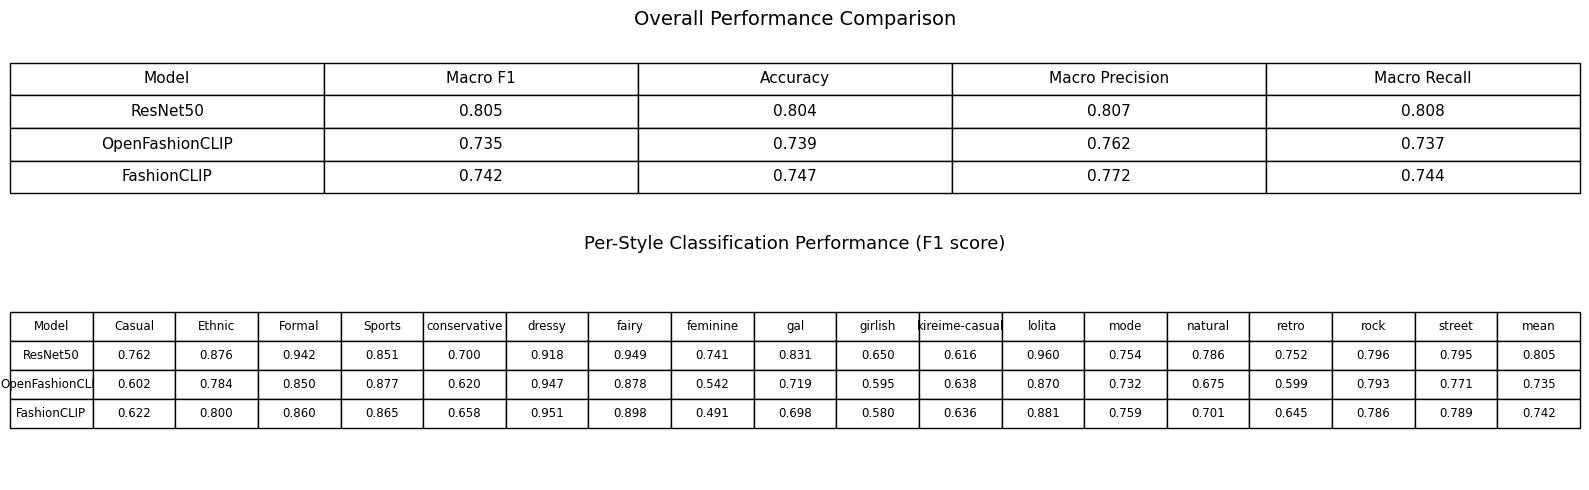

Saved: baseline_result\figures\baseline_comparison_table.png


In [32]:
figure_path = os.path.join(FIG_DIR, "baseline_comparison_table.png")
draw_comparison_figure(overall_df, per_style_compare, figure_path)
print("Saved:", figure_path)

# Fine-Tuning Experiments for OpenFashionCLIP and FashionCLIP

This notebook runs multiple training strategies for fashion style classification.

<b>Workflow</b>
1. Load Data
2. Training
3. Inference
4. Evaluation

<b>Models</b>
- OpenFashionCLIP
- FashionCLIP

<b>Training Strategies</b>
- Partial Fine-Tuning
- Text-Prompt Classification
- Full Fine-Tuning
- PEFT / LoRA

<b>Saved Outputs</b>
For each experiment, the notebook saves:
- best checkpoint
- training history
- test inference results
- overall evaluation results
- per-style evaluation results

All experiment results are saved under:
`1_exp/0318/ft_result`

In [34]:
import os
import json
import copy
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import open_clip
from transformers import AutoProcessor, AutoTokenizer, CLIPModel

warnings.filterwarnings("ignore")

STYLE_DATA_DIR = os.path.join("..", "..", "1_data", "Style_dataset")

TRAIN_CSV = os.path.join(STYLE_DATA_DIR, "train.csv")
VAL_CSV   = os.path.join(STYLE_DATA_DIR, "val.csv")
TEST_CSV  = os.path.join(STYLE_DATA_DIR, "test.csv")

TRAIN_IMG_DIR = os.path.join(STYLE_DATA_DIR, "images", "train")
VAL_IMG_DIR   = os.path.join(STYLE_DATA_DIR, "images", "val")
TEST_IMG_DIR  = os.path.join(STYLE_DATA_DIR, "images", "test")

EXP_ROOT = os.path.join("ft_result")
os.makedirs(EXP_ROOT, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 10
HEAD_LR = 1e-4
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4

OPENFASHIONCLIP_MODEL_NAME = "ViT-B-32"
OPENFASHIONCLIP_PRETRAINED = "laion2b_s34b_b79k"
FASHIONCLIP_MODEL_ID = "patrickjohncyh/fashion-clip"

print("Experiment root:", EXP_ROOT)
print("Device:", DEVICE)

Experiment root: ft_result
Device: cuda


In [35]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Load Data
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df["id"] = train_df["id"].astype(str)
val_df["id"]   = val_df["id"].astype(str)
test_df["id"]  = test_df["id"].astype(str)

style_names = sorted(train_df["style"].unique())
label2idx = {label: idx for idx, label in enumerate(style_names)}
idx2label = {idx: label for label, idx in label2idx.items()}
num_classes = len(style_names)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
print("Classes:", num_classes)
print(style_names)


# image lookup
VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

def build_image_lookup(image_dir):
    lookup = {}
    for fname in os.listdir(image_dir):
        fpath = os.path.join(image_dir, fname)
        if not os.path.isfile(fpath):
            continue
        stem, ext = os.path.splitext(fname)
        if ext.lower() in VALID_EXTS:
            lookup[stem] = fpath
    return lookup

train_lookup = build_image_lookup(TRAIN_IMG_DIR)
val_lookup   = build_image_lookup(VAL_IMG_DIR)
test_lookup  = build_image_lookup(TEST_IMG_DIR)

print("Train images:", len(train_lookup))
print("Val images:", len(val_lookup))
print("Test images:", len(test_lookup))

# Datasets
class StyleImageDataset(Dataset):
    def __init__(self, df, image_lookup, label2idx, image_transform=None):
        self.image_lookup = image_lookup
        self.label2idx = label2idx
        self.image_transform = image_transform

        rows = []
        missing = 0

        for _, row in df.iterrows():
            image_id = str(row["id"])
            if image_id in self.image_lookup:
                rows.append(row)
            else:
                missing += 1

        self.df = pd.DataFrame(rows).reset_index(drop=True)
        print(f"Dataset initialized with {len(self.df)} rows, missing images skipped: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["id"])
        label_name = row["style"]
        label = self.label2idx[label_name]

        image = Image.open(self.image_lookup[image_id]).convert("RGB")

        if self.image_transform is not None:
            image = self.image_transform(image)

        return {
            "id": image_id,
            "image": image,
            "label": label,
            "label_name": label_name
        }

Train: (11775, 2)
Val: (2523, 2)
Test: (2537, 2)
Classes: 17
['Casual', 'Ethnic', 'Formal', 'Sports', 'conservative', 'dressy', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Train images: 11775
Val images: 2523
Test images: 2537


## Preprocessor and Dataloader

In [36]:
openclip_model_tmp, _, openclip_preprocess = open_clip.create_model_and_transforms(
    OPENFASHIONCLIP_MODEL_NAME,
    pretrained=OPENFASHIONCLIP_PRETRAINED
)
del openclip_model_tmp

fashionclip_processor = AutoProcessor.from_pretrained(FASHIONCLIP_MODEL_ID)

def fashionclip_collate_fn(batch):
    images = [x["image"] for x in batch]
    labels = torch.tensor([x["label"] for x in batch], dtype=torch.long)
    ids = [x["id"] for x in batch]
    label_names = [x["label_name"] for x in batch]

    pixel_values = fashionclip_processor(images=images, return_tensors="pt")["pixel_values"]

    return {
        "id": ids,
        "image": pixel_values,
        "label": labels,
        "label_name": label_names
    }

open_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, image_transform=openclip_preprocess)
open_val_ds   = StyleImageDataset(val_df, val_lookup, label2idx, image_transform=openclip_preprocess)
open_test_ds  = StyleImageDataset(test_df, test_lookup, label2idx, image_transform=openclip_preprocess)

open_train_loader = DataLoader(open_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
open_val_loader   = DataLoader(open_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
open_test_loader  = DataLoader(open_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

fclip_train_ds = StyleImageDataset(train_df, train_lookup, label2idx, image_transform=None)
fclip_val_ds   = StyleImageDataset(val_df, val_lookup, label2idx, image_transform=None)
fclip_test_ds  = StyleImageDataset(test_df, test_lookup, label2idx, image_transform=None)

fclip_train_loader = DataLoader(
    fclip_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=fashionclip_collate_fn
)

fclip_val_loader = DataLoader(
    fclip_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=fashionclip_collate_fn
)

fclip_test_loader = DataLoader(
    fclip_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=fashionclip_collate_fn
)

Dataset initialized with 11775 rows, missing images skipped: 0
Dataset initialized with 2523 rows, missing images skipped: 0
Dataset initialized with 2537 rows, missing images skipped: 0
Dataset initialized with 11775 rows, missing images skipped: 0
Dataset initialized with 2523 rows, missing images skipped: 0
Dataset initialized with 2537 rows, missing images skipped: 0


## Experiment Utilities

In [37]:
def create_exp_dirs(exp_name):
    exp_dir = os.path.join(EXP_ROOT, exp_name)
    ckpt_dir = os.path.join(exp_dir, "checkpoints")
    pred_dir = os.path.join(exp_dir, "predictions")
    metric_dir = os.path.join(exp_dir, "metrics")
    fig_dir = os.path.join(exp_dir, "figures")
    log_dir = os.path.join(exp_dir, "logs")

    for p in [exp_dir, ckpt_dir, pred_dir, metric_dir, fig_dir, log_dir]:
        os.makedirs(p, exist_ok=True)

    return {
        "exp_dir": exp_dir,
        "ckpt_dir": ckpt_dir,
        "pred_dir": pred_dir,
        "metric_dir": metric_dir,
        "fig_dir": fig_dir,
        "log_dir": log_dir
    }

# Metrics utilities
def compute_metrics(y_true, y_pred, idx2label):
    acc = accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    label_ids = list(range(len(idx2label)))
    per_precision, per_recall, per_f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=label_ids, average=None, zero_division=0
    )

    per_style_df = pd.DataFrame({
        "style": [idx2label[i] for i in label_ids],
        "precision": per_precision,
        "recall": per_recall,
        "f1": per_f1,
        "support": support
    })

    overall = {
        "Macro F1": macro_f1,
        "Accuracy": acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall
    }

    return overall, per_style_df

# Freezing Utilities
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

def unfreeze_last_openclip_blocks(model, n_last_blocks=2):
    freeze_all(model)
    for p in model.classifier.parameters():
        p.requires_grad = True

    if hasattr(model.backbone.visual, "transformer") and hasattr(model.backbone.visual.transformer, "resblocks"):
        blocks = model.backbone.visual.transformer.resblocks
        for block in list(blocks)[-n_last_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

def unfreeze_last_fashionclip_blocks(model, n_last_blocks=2):
    freeze_all(model)
    for p in model.classifier.parameters():
        p.requires_grad = True

    if hasattr(model.backbone.vision_model.encoder, "layers"):
        blocks = model.backbone.vision_model.encoder.layers
        for block in list(blocks)[-n_last_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

## Models

In [38]:
# Base Models
class OpenFashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_name, pretrained):
        super().__init__()
        self.backbone = open_clip.create_model(model_name, pretrained=pretrained)

        if hasattr(self.backbone.visual, "output_dim"):
            feat_dim = self.backbone.visual.output_dim
        else:
            raise ValueError("Could not determine OpenFashionCLIP visual output dimension.")

        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        image_features = self.backbone.encode_image(pixel_values)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits
    
class FashionCLIPClassifier(nn.Module):
    def __init__(self, num_classes, model_id):
        super().__init__()
        self.backbone = CLIPModel.from_pretrained(model_id)
        feat_dim = self.backbone.config.projection_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits
    
# Prompt-based Models
class OpenFashionCLIPPromptClassifier(nn.Module):
    def __init__(self, style_names, model_name, pretrained, prompt_template="a photo of a {} fashion outfit"):
        super().__init__()
        self.backbone = open_clip.create_model(model_name, pretrained=pretrained)
        self.tokenizer = open_clip.get_tokenizer(model_name)

        prompts = [prompt_template.format(style) for style in style_names]
        tokenized = self.tokenizer(prompts)

        with torch.no_grad():
            text_features = self.backbone.encode_text(tokenized)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("text_features", text_features)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))

        feat_dim = text_features.shape[1]
        self.adapter = nn.Linear(feat_dim, feat_dim)
        nn.init.eye_(self.adapter.weight)
        nn.init.zeros_(self.adapter.bias)

    def forward(self, pixel_values):
        image_features = self.backbone.encode_image(pixel_values)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        image_features = self.adapter(image_features)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = self.logit_scale.exp() * image_features @ self.text_features.T
        return logits
    
class FashionCLIPPromptClassifier(nn.Module):
    def __init__(self, style_names, model_id, prompt_template="a photo of a {} fashion outfit"):
        super().__init__()
        self.backbone = CLIPModel.from_pretrained(model_id)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)

        prompts = [prompt_template.format(style) for style in style_names]
        text_inputs = self.tokenizer(prompts, padding=True, truncation=True, return_tensors="pt")

        with torch.no_grad():
            text_outputs = self.backbone.text_model(
                input_ids=text_inputs["input_ids"],
                attention_mask=text_inputs["attention_mask"]
            )

            pooled_text = text_outputs.pooler_output
            text_features = self.backbone.text_projection(pooled_text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("text_features", text_features)

        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))

        feat_dim = text_features.shape[1]
        self.adapter = nn.Linear(feat_dim, feat_dim)
        nn.init.eye_(self.adapter.weight)
        nn.init.zeros_(self.adapter.bias)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_image = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_image)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        image_features = self.adapter(image_features)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = self.logit_scale.exp() * image_features @ self.text_features.T
        return logits
    
# LoRA Model
try:
    from peft import LoraConfig, get_peft_model
    PEFT_AVAILABLE = True
except Exception:
    PEFT_AVAILABLE = False

print("PEFT available:", PEFT_AVAILABLE)

class FashionCLIPLoRAClassifier(nn.Module):
    def __init__(self, num_classes, model_id):
        super().__init__()
        base_model = CLIPModel.from_pretrained(model_id)

        if not PEFT_AVAILABLE:
            raise ImportError("peft is not installed. Please install peft before running LoRA experiments.")

        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
            lora_dropout=0.1,
            bias="none"
        )

        self.backbone = get_peft_model(base_model, lora_config)
        feat_dim = self.backbone.config.projection_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, pixel_values):
        vision_outputs = self.backbone.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        image_features = self.backbone.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits
    

# Optimizer
def build_optimizer(model, head_lr=1e-4, backbone_lr=1e-5, weight_decay=1e-4):
    head_params = []
    backbone_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if "classifier" in name or "adapter" in name or "logit_scale" in name:
            head_params.append(p)
        else:
            backbone_params.append(p)

    param_groups = []
    if head_params:
        param_groups.append({"params": head_params, "lr": head_lr})
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": backbone_lr})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=weight_decay)
    return optimizer

PEFT available: True


## Training Function

In [39]:
def train_model(
    exp_name,
    model,
    train_loader,
    val_loader,
    num_epochs,
    idx2label,
    save_dirs,
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4
):
    model = model.to(DEVICE)
    optimizer = build_optimizer(model, head_lr=head_lr, backbone_lr=backbone_lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_f1 = -1
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for batch in tqdm(train_loader, desc=f"{exp_name} Train Epoch {epoch}", leave=False):
            images = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * labels.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        all_true = []
        all_pred = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"{exp_name} Val Epoch {epoch}", leave=False):
                images = batch["image"].to(DEVICE)
                labels = batch["label"].to(DEVICE)

                logits = model(images)
                loss = criterion(logits, labels)

                preds = torch.argmax(logits, dim=1)

                val_loss_sum += loss.item() * labels.size(0)
                all_true.extend(labels.cpu().numpy().tolist())
                all_pred.extend(preds.cpu().numpy().tolist())

        val_loss = val_loss_sum / len(val_loader.dataset)
        overall, _ = compute_metrics(all_true, all_pred, idx2label)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_macro_f1": overall["Macro F1"],
            "val_accuracy": overall["Accuracy"],
            "val_macro_precision": overall["Macro Precision"],
            "val_macro_recall": overall["Macro Recall"]
        }
        history.append(row)

        if overall["Macro F1"] > best_val_f1:
            best_val_f1 = overall["Macro F1"]
            best_state = copy.deepcopy(model.state_dict())

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(save_dirs["log_dir"], "training_history.csv"), index=False)

    ckpt_path = os.path.join(save_dirs["ckpt_dir"], "best.pt")
    torch.save(best_state, ckpt_path)

    return {
        "best_ckpt_path": ckpt_path,
        "history_df": history_df,
        "best_val_f1": best_val_f1
    }

## Inference Function

In [40]:
@torch.no_grad()
def run_inference(model, loader, save_path):
    model.eval()

    all_ids = []
    all_true = []
    all_pred = []

    for batch in tqdm(loader, desc="Inference", leave=False):
        images = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_ids.extend(batch["id"])
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    pred_df = pd.DataFrame({
        "id": all_ids,
        "true_idx": all_true,
        "pred_idx": all_pred,
        "true_label": [idx2label[i] for i in all_true],
        "pred_label": [idx2label[i] for i in all_pred]
    })
    pred_df["correct"] = (pred_df["true_idx"] == pred_df["pred_idx"]).astype(int)

    pred_df.to_csv(save_path, index=False)
    return pred_df

## Evaluation Function

In [41]:
def evaluate_predictions(pred_df, metric_dir):
    y_true = pred_df["true_idx"].tolist()
    y_pred = pred_df["pred_idx"].tolist()

    overall, per_style_df = compute_metrics(y_true, y_pred, idx2label)

    overall_df = pd.DataFrame([overall])
    overall_df.to_csv(os.path.join(metric_dir, "overall_metrics.csv"), index=False)
    per_style_df.to_csv(os.path.join(metric_dir, "per_style_metrics.csv"), index=False)

    return overall_df, per_style_df

## Experiment

In [42]:
def build_experiment(exp_name):
    if exp_name == "openfashionclip_partial_ft":
        model = OpenFashionCLIPClassifier(num_classes, OPENFASHIONCLIP_MODEL_NAME, OPENFASHIONCLIP_PRETRAINED)
        unfreeze_last_openclip_blocks(model, n_last_blocks=2)
        train_loader, val_loader, test_loader = open_train_loader, open_val_loader, open_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "openfashionclip_full_ft":
        model = OpenFashionCLIPClassifier(num_classes, OPENFASHIONCLIP_MODEL_NAME, OPENFASHIONCLIP_PRETRAINED)
        unfreeze_all(model)
        train_loader, val_loader, test_loader = open_train_loader, open_val_loader, open_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "openfashionclip_prompt":
        model = OpenFashionCLIPPromptClassifier(style_names, OPENFASHIONCLIP_MODEL_NAME, OPENFASHIONCLIP_PRETRAINED)
        freeze_all(model.backbone)
        for p in model.adapter.parameters():
            p.requires_grad = True
        model.logit_scale.requires_grad = True
        train_loader, val_loader, test_loader = open_train_loader, open_val_loader, open_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "fashionclip_partial_ft":
        model = FashionCLIPClassifier(num_classes, FASHIONCLIP_MODEL_ID)
        unfreeze_last_fashionclip_blocks(model, n_last_blocks=2)
        train_loader, val_loader, test_loader = fclip_train_loader, fclip_val_loader, fclip_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "fashionclip_full_ft":
        model = FashionCLIPClassifier(num_classes, FASHIONCLIP_MODEL_ID)
        unfreeze_all(model)
        train_loader, val_loader, test_loader = fclip_train_loader, fclip_val_loader, fclip_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "fashionclip_prompt":
        model = FashionCLIPPromptClassifier(style_names, FASHIONCLIP_MODEL_ID)
        freeze_all(model.backbone)
        for p in model.adapter.parameters():
            p.requires_grad = True
        model.logit_scale.requires_grad = True
        train_loader, val_loader, test_loader = fclip_train_loader, fclip_val_loader, fclip_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "fashionclip_lora":
        model = FashionCLIPLoRAClassifier(num_classes, FASHIONCLIP_MODEL_ID)
        for p in model.classifier.parameters():
            p.requires_grad = True
        train_loader, val_loader, test_loader = fclip_train_loader, fclip_val_loader, fclip_test_loader
        return model, train_loader, val_loader, test_loader

    if exp_name == "openfashionclip_lora":
        raise NotImplementedError(
            "OpenFashionCLIP LoRA is not included in this runner because the current open_clip backbone "
            "does not provide a stable plug-and-play LoRA path across implementations."
        )

    raise ValueError(f"Unknown experiment name: {exp_name}")

# reload model helper
def rebuild_model_for_inference(exp_name, ckpt_path):
    model, _, _, test_loader = build_experiment(exp_name)
    state_dict = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model = model.to(DEVICE)
    return model, test_loader

# single experiment runner
def run_single_experiment(exp_name):
    print(f"\n===== Running {exp_name} =====")

    save_dirs = create_exp_dirs(exp_name)
    model, train_loader, val_loader, test_loader = build_experiment(exp_name)

    train_result = train_model(
        exp_name=exp_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        idx2label=idx2label,
        save_dirs=save_dirs,
        head_lr=HEAD_LR,
        backbone_lr=BACKBONE_LR,
        weight_decay=WEIGHT_DECAY
    )

    inference_model, test_loader = rebuild_model_for_inference(exp_name, train_result["best_ckpt_path"])

    pred_path = os.path.join(save_dirs["pred_dir"], "test_predictions.csv")
    pred_df = run_inference(inference_model, test_loader, pred_path)

    overall_df, per_style_df = evaluate_predictions(pred_df, save_dirs["metric_dir"])

    result = {
        "experiment": exp_name,
        "overall_df": overall_df,
        "per_style_df": per_style_df,
        "best_ckpt_path": train_result["best_ckpt_path"],
        "prediction_path": pred_path
    }

    return result

# Run All Experiments
experiment_names = [
    "openfashionclip_partial_ft",
    "openfashionclip_prompt",
    "openfashionclip_full_ft",
    "fashionclip_partial_ft",
    "fashionclip_prompt",
    "fashionclip_full_ft",
    "fashionclip_lora"
]

all_results = []

for exp_name in experiment_names:
    try:
        result = run_single_experiment(exp_name)
        all_results.append(result)
    except Exception as e:
        print(f"Experiment failed: {exp_name}")
        print(str(e))


===== Running openfashionclip_partial_ft =====



===== Running openfashionclip_prompt =====



===== Running openfashionclip_full_ft =====



===== Running fashionclip_partial_ft =====


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10473.79it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10204.74it/s]                   
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8651.86it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9950.13it/s]                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Running fashionclip_full_ft =====


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9949.77it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10757.12it/s]                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Running fashionclip_lora =====


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9256.33it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10758.09it/s]             
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Training Loss Curve

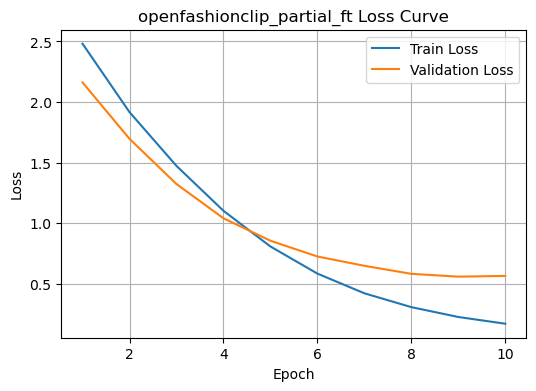

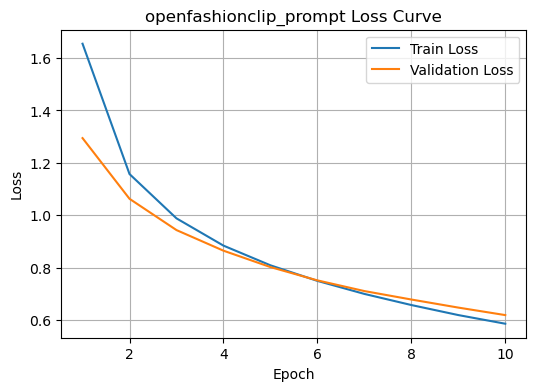

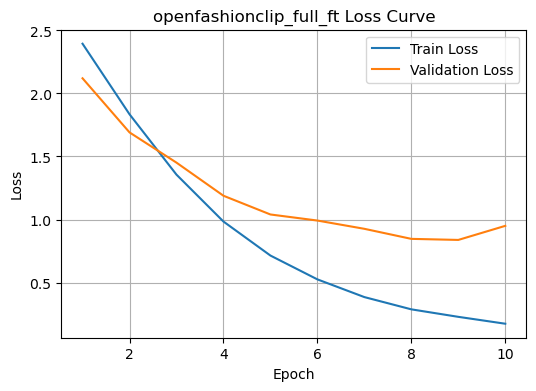

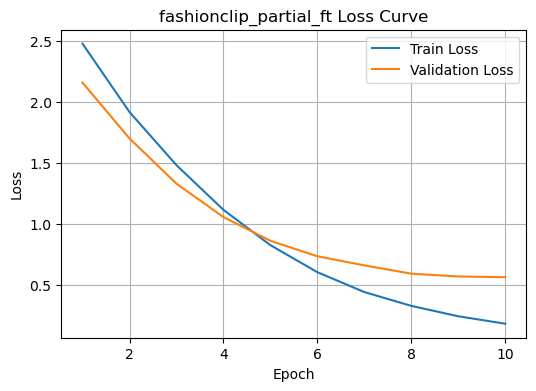

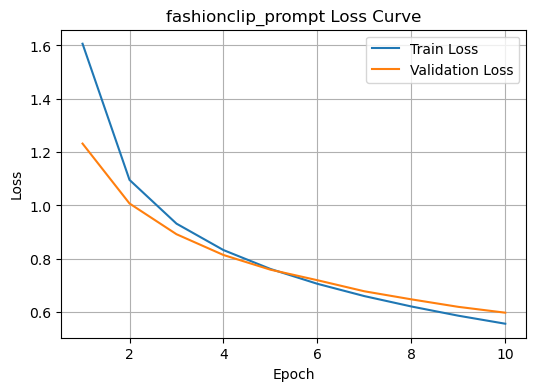

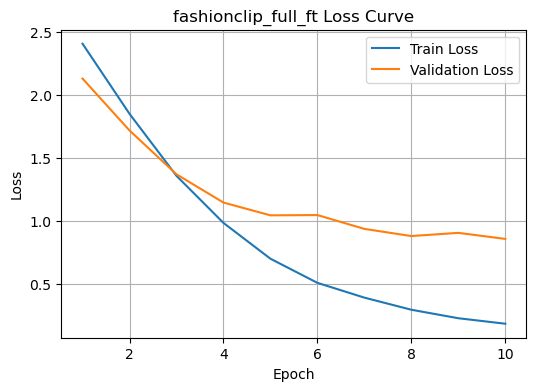

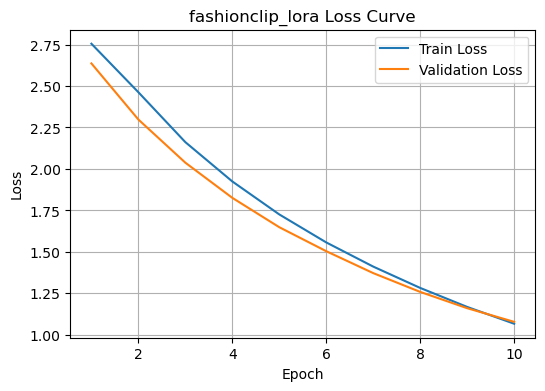

In [43]:
for exp in experiment_names:

    history_path = os.path.join(
        EXP_ROOT,
        exp,
        "logs",
        "training_history.csv"
    )

    if not os.path.exists(history_path):
        print(f"Skip {exp}, training history not found")
        continue

    df = pd.read_csv(history_path)

    plt.figure(figsize=(6,4))

    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{exp} Loss Curve")

    plt.legend()
    plt.grid(True)
    plt.show()


## Summary and Evaluation

In [44]:
summary_dir = os.path.join(EXP_ROOT, "summary")
os.makedirs(summary_dir, exist_ok=True)

overall_rows = []
per_style_merge = pd.DataFrame({"style": style_names})

for result in all_results:
    exp_name = result["experiment"]
    row = result["overall_df"].iloc[0].to_dict()
    row["Experiment"] = exp_name
    overall_rows.append(row)

    style_df = result["per_style_df"][["style", "f1"]].rename(columns={"f1": exp_name})
    per_style_merge = per_style_merge.merge(style_df, on="style", how="left")

overall_summary_df = pd.DataFrame(overall_rows)
overall_summary_df = overall_summary_df[["Experiment", "Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]]
overall_summary_df.to_csv(os.path.join(summary_dir, "overall_performance_comparison.csv"), index=False)

per_style_merge.to_csv(os.path.join(summary_dir, "per_style_f1_comparison.csv"), index=False)

print(overall_summary_df)
print(per_style_merge.head())

                   Experiment  Macro F1  Accuracy  Macro Precision  \
0  openfashionclip_partial_ft  0.868726  0.867560         0.871561   
1      openfashionclip_prompt  0.863992  0.862436         0.865504   
2     openfashionclip_full_ft  0.783991  0.782814         0.792480   
3      fashionclip_partial_ft  0.861883  0.861253         0.864694   
4          fashionclip_prompt  0.854352  0.853370         0.855812   
5         fashionclip_full_ft  0.788248  0.785574         0.798819   
6            fashionclip_lora  0.732026  0.734332         0.736207   

   Macro Recall  
0      0.868517  
1      0.863732  
2      0.784441  
3      0.861109  
4      0.854966  
5      0.788221  
6      0.737822  
          style  openfashionclip_partial_ft  openfashionclip_prompt  \
0        Casual                    0.828070                0.817568   
1        Ethnic                    0.918919                0.926174   
2        Formal                    0.943144                0.929293   
3        Sp

## Comparison Figure

In [45]:
def draw_final_comparison_figure(overall_df, per_style_df, save_path):
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.3])

    ax1 = fig.add_subplot(gs[0])
    ax1.axis("off")
    ax1.set_title("Overall Performance Comparison", fontsize=14, pad=8)

    show_overall = overall_df.copy()
    for col in ["Macro F1", "Accuracy", "Macro Precision", "Macro Recall"]:
        show_overall[col] = show_overall[col].map(lambda x: f"{x:.3f}")

    table1 = ax1.table(
        cellText=show_overall.values,
        colLabels=show_overall.columns,
        cellLoc="center",
        loc="center"
    )
    table1.auto_set_font_size(False)
    table1.set_fontsize(10)
    table1.scale(1, 1.6)

    ax2 = fig.add_subplot(gs[1])
    ax2.axis("off")
    ax2.set_title("Per-Style Classification Performance (F1 score)", fontsize=13, pad=8)

    bottom_df = per_style_df.copy().T
    bottom_df.columns = bottom_df.iloc[0]
    bottom_df = bottom_df.iloc[1:].reset_index()
    bottom_df = bottom_df.rename(columns={"index": "Experiment"})

    style_cols = [c for c in bottom_df.columns if c != "Experiment"]
    bottom_df["mean"] = bottom_df[style_cols].astype(float).mean(axis=1)

    for col in bottom_df.columns:
        if col != "Experiment":
            bottom_df[col] = bottom_df[col].map(lambda x: f"{float(x):.3f}")

    table2 = ax2.table(
        cellText=bottom_df.values,
        colLabels=bottom_df.columns,
        cellLoc="center",
        loc="center"
    )
    table2.auto_set_font_size(False)
    table2.set_fontsize(8)
    table2.scale(1, 1.4)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

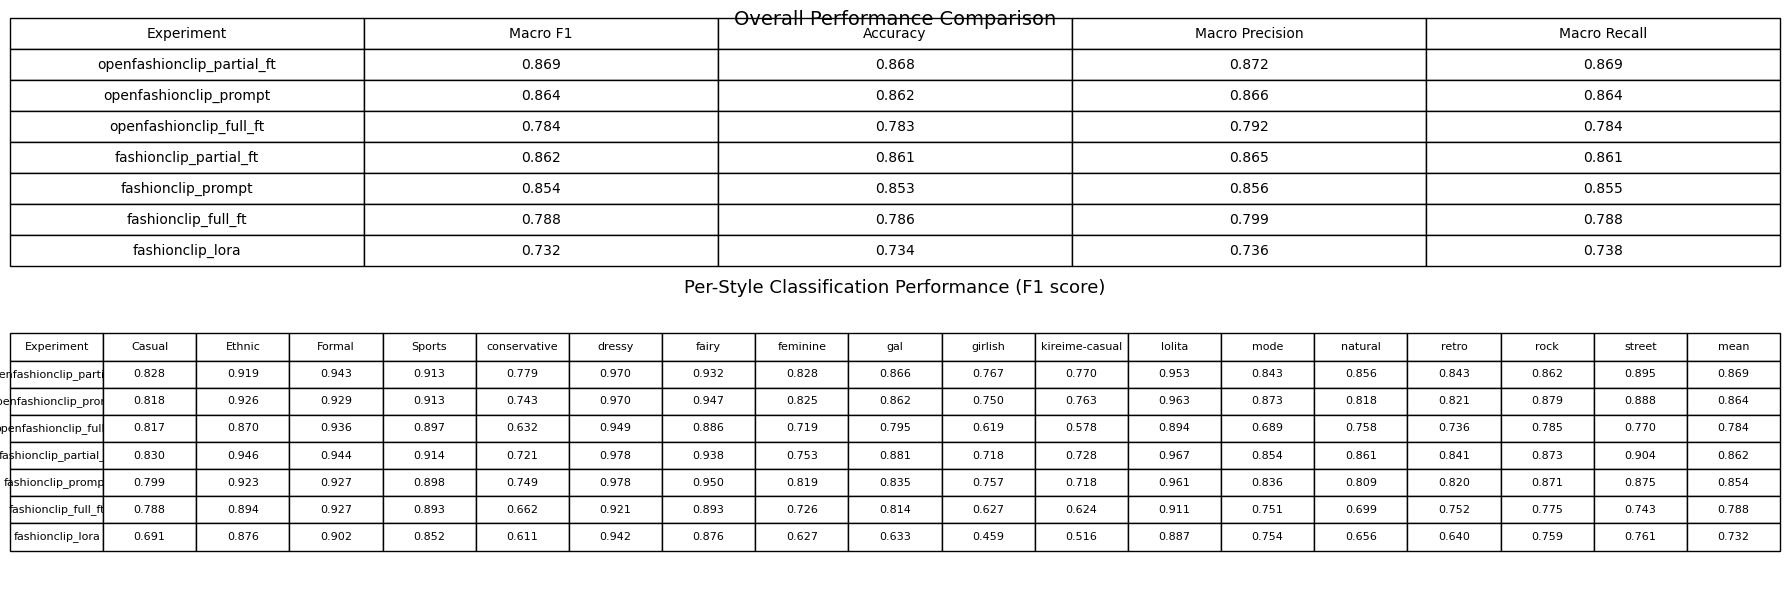

Saved: ft_result\summary\final_comparison_figure.png


In [46]:
final_fig_path = os.path.join(summary_dir, "final_comparison_figure.png")
draw_final_comparison_figure(overall_summary_df, per_style_merge, final_fig_path)
print("Saved:", final_fig_path)

## Save Experiment Index

In [ ]:
experiment_index = []

for result in all_results:
    experiment_index.append({
        "experiment": result["experiment"],
        "best_ckpt_path": result["best_ckpt_path"],
        "prediction_path": result["prediction_path"]
    })

experiment_index_df = pd.DataFrame(experiment_index)
experiment_index_df.to_csv(os.path.join(summary_dir, "experiment_index.csv"), index=False)
experiment_index_df

,experiment,best_ckpt_path,prediction_path
0,openfashionclip_partial_ft,ft_result\openfashionclip_partial_ft\checkpoin...,ft_result\openfashionclip_partial_ft\predictio...
1,openfashionclip_prompt,ft_result\openfashionclip_prompt\checkpoints\b...,ft_result\openfashionclip_prompt\predictions\t...
2,openfashionclip_full_ft,ft_result\openfashionclip_full_ft\checkpoints\...,ft_result\openfashionclip_full_ft\predictions\...
3,fashionclip_partial_ft,ft_result\fashionclip_partial_ft\checkpoints\b...,ft_result\fashionclip_partial_ft\predictions\t...
4,fashionclip_full_ft,ft_result\fashionclip_full_ft\checkpoints\best.pt,ft_result\fashionclip_full_ft\predictions\test...
5,fashionclip_lora,ft_result\fashionclip_lora\checkpoints\best.pt,ft_result\fashionclip_lora\predictions\test_pr...


# Confusion Metrics

Missing baseline file: baseline_results/predictions\FashionCLIP_test_predictions.csv
Missing baseline file: baseline_results/predictions\OpenFashionCLIP_test_predictions.csv
Missing baseline file: baseline_results/predictions\ResNet50_test_predictions.csv

Loading predictions for: openfashionclip_partial_ft
Path: ft_result\openfashionclip_partial_ft\predictions\test_predictions.csv

openfashionclip_partial_ft


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,openfashionclip_partial_ft,"2,537",0.8676,0.8716,0.8685,0.8687


,label,precision,recall,f1,support
0,dressy,0.9630,0.9774,0.9701,133
1,lolita,0.9404,0.9660,0.9530,147
2,Formal,0.9463,0.9400,0.9431,150
3,fairy,0.9254,0.9394,0.9323,132
4,Ethnic,0.9315,0.9067,0.9189,150
5,Sports,0.8820,0.9467,0.9132,150
6,street,0.8902,0.9006,0.8953,171
7,gal,0.9172,0.8210,0.8664,162
8,rock,0.8397,0.8851,0.8618,148
9,natural,0.8993,0.8170,0.8562,153


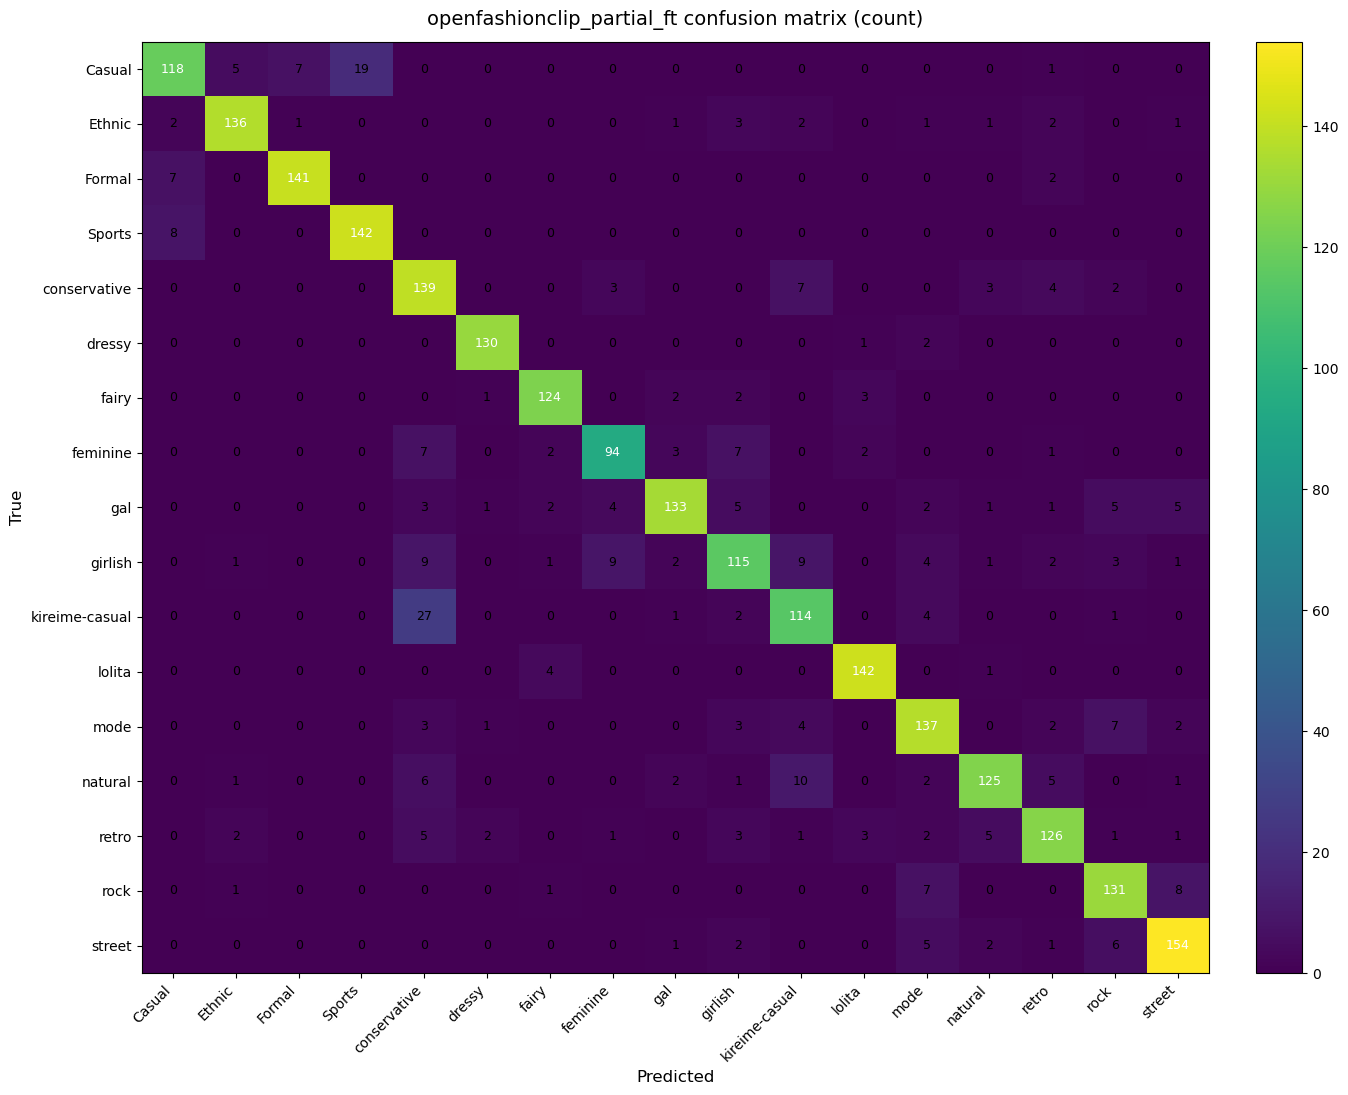

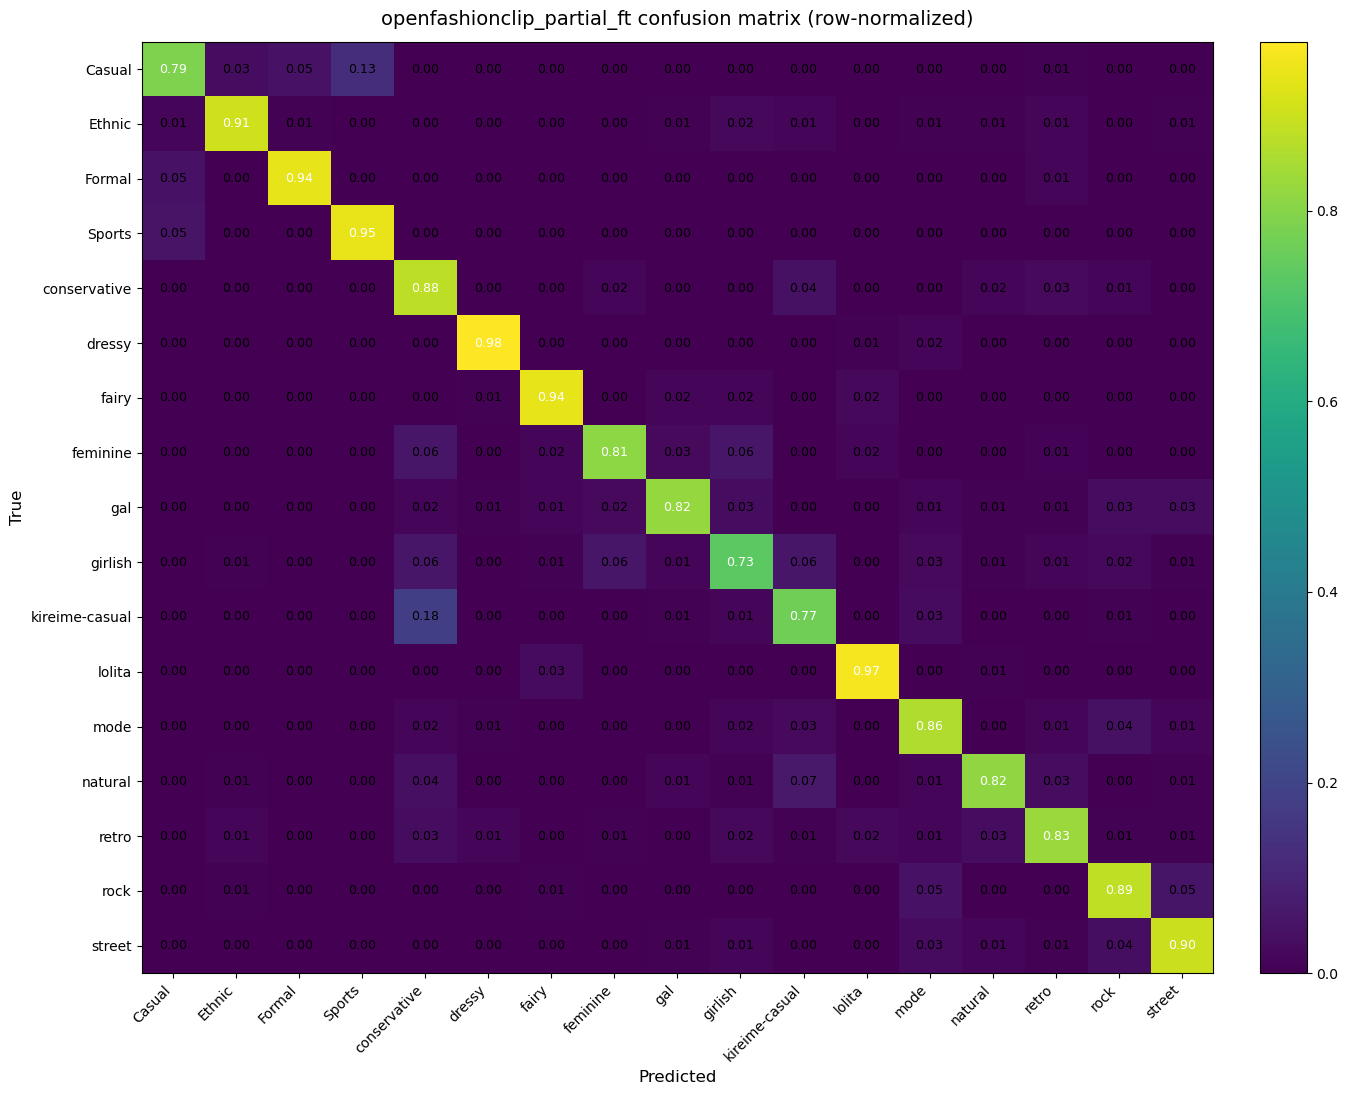


Loading predictions for: openfashionclip_prompt
Path: ft_result\openfashionclip_prompt\predictions\test_predictions.csv

openfashionclip_prompt


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,openfashionclip_prompt,"2,537",0.8624,0.8655,0.8637,0.8640


,label,precision,recall,f1,support
0,dressy,0.9699,0.9699,0.9699,133
1,lolita,0.9416,0.9864,0.9635,147
2,fairy,0.9470,0.9470,0.9470,132
3,Formal,0.9388,0.9200,0.9293,150
4,Ethnic,0.9324,0.9200,0.9262,150
5,Sports,0.9189,0.9067,0.9128,150
6,street,0.8982,0.8772,0.8876,171
7,rock,0.8491,0.9122,0.8795,148
8,mode,0.8598,0.8868,0.8731,159
9,gal,0.8993,0.8272,0.8617,162


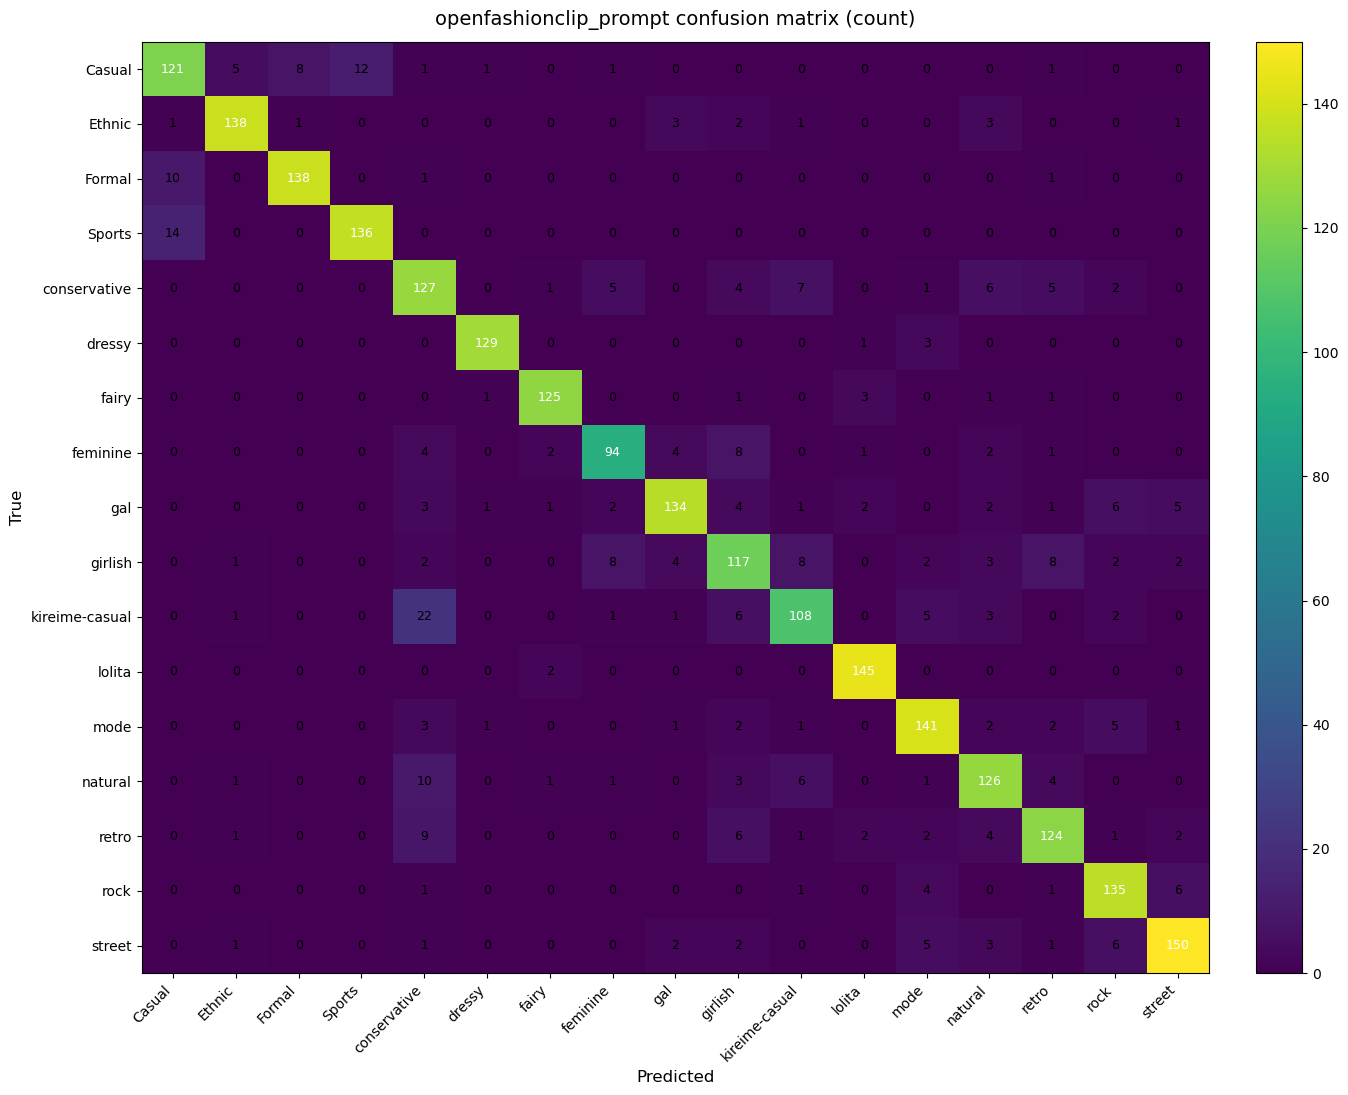

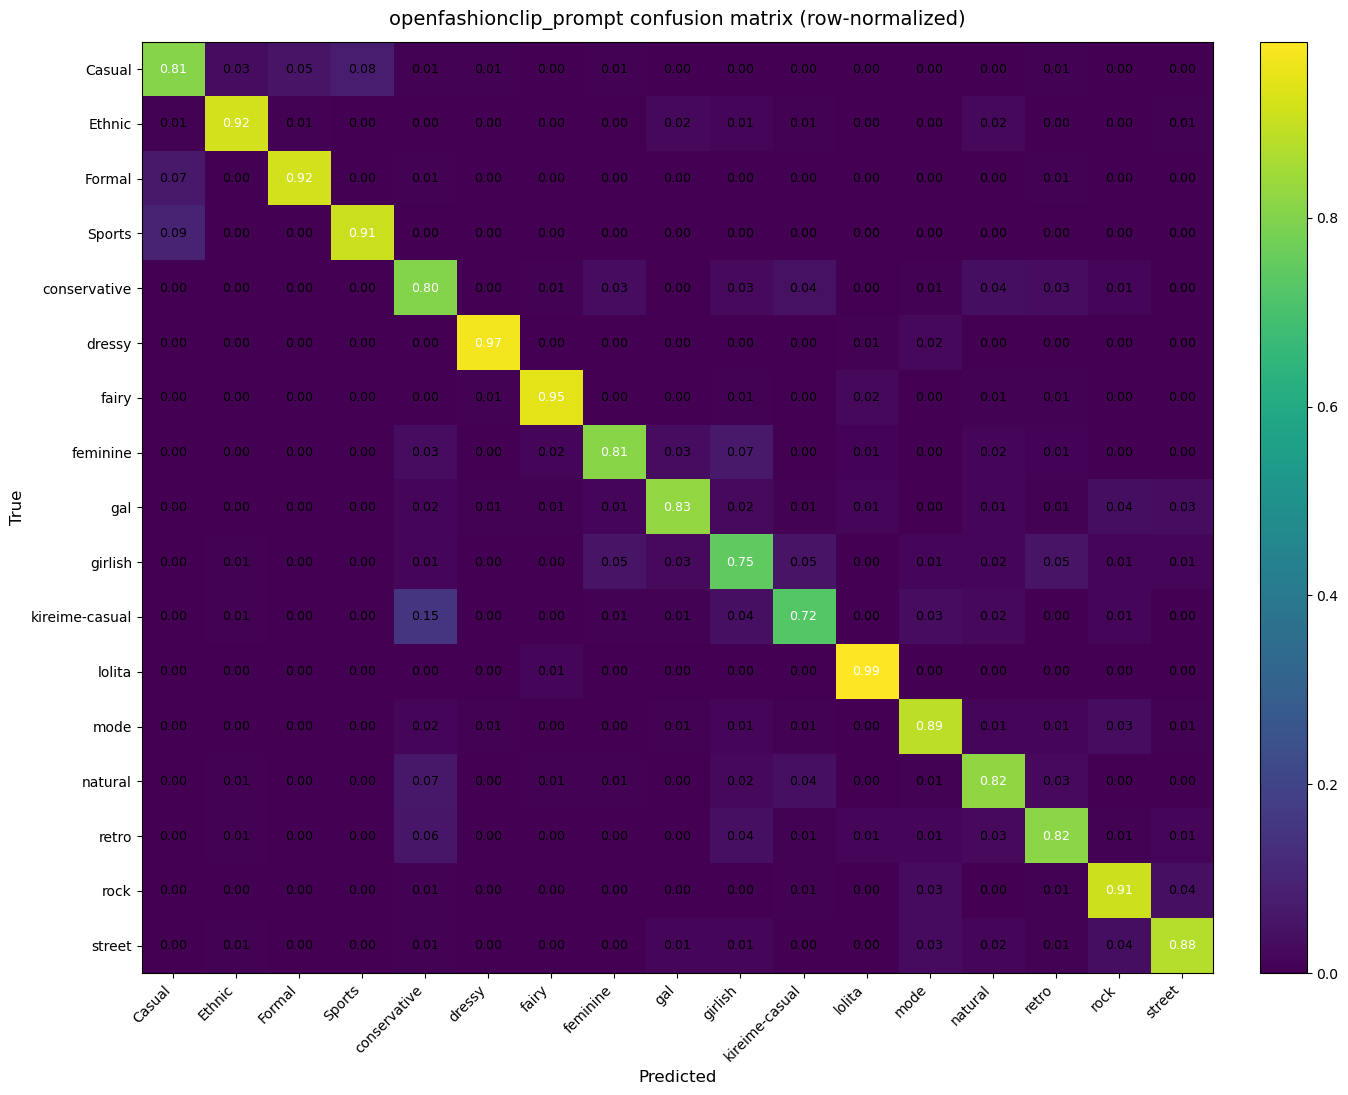


Loading predictions for: openfashionclip_full_ft
Path: ft_result\openfashionclip_full_ft\predictions\test_predictions.csv

openfashionclip_full_ft


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,openfashionclip_full_ft,"2,537",0.7828,0.7925,0.7844,0.7840


,label,precision,recall,f1,support
0,dressy,0.9918,0.9098,0.9490,133
1,Formal,0.9517,0.9200,0.9356,150
2,Sports,0.9286,0.8667,0.8966,150
3,lolita,0.9333,0.8571,0.8936,147
4,fairy,0.8378,0.9394,0.8857,132
5,Ethnic,0.9185,0.8267,0.8702,150
6,Casual,0.7888,0.8467,0.8167,150
7,gal,0.7765,0.8148,0.7952,162
8,rock,0.7104,0.8784,0.7855,148
9,street,0.6667,0.9123,0.7704,171


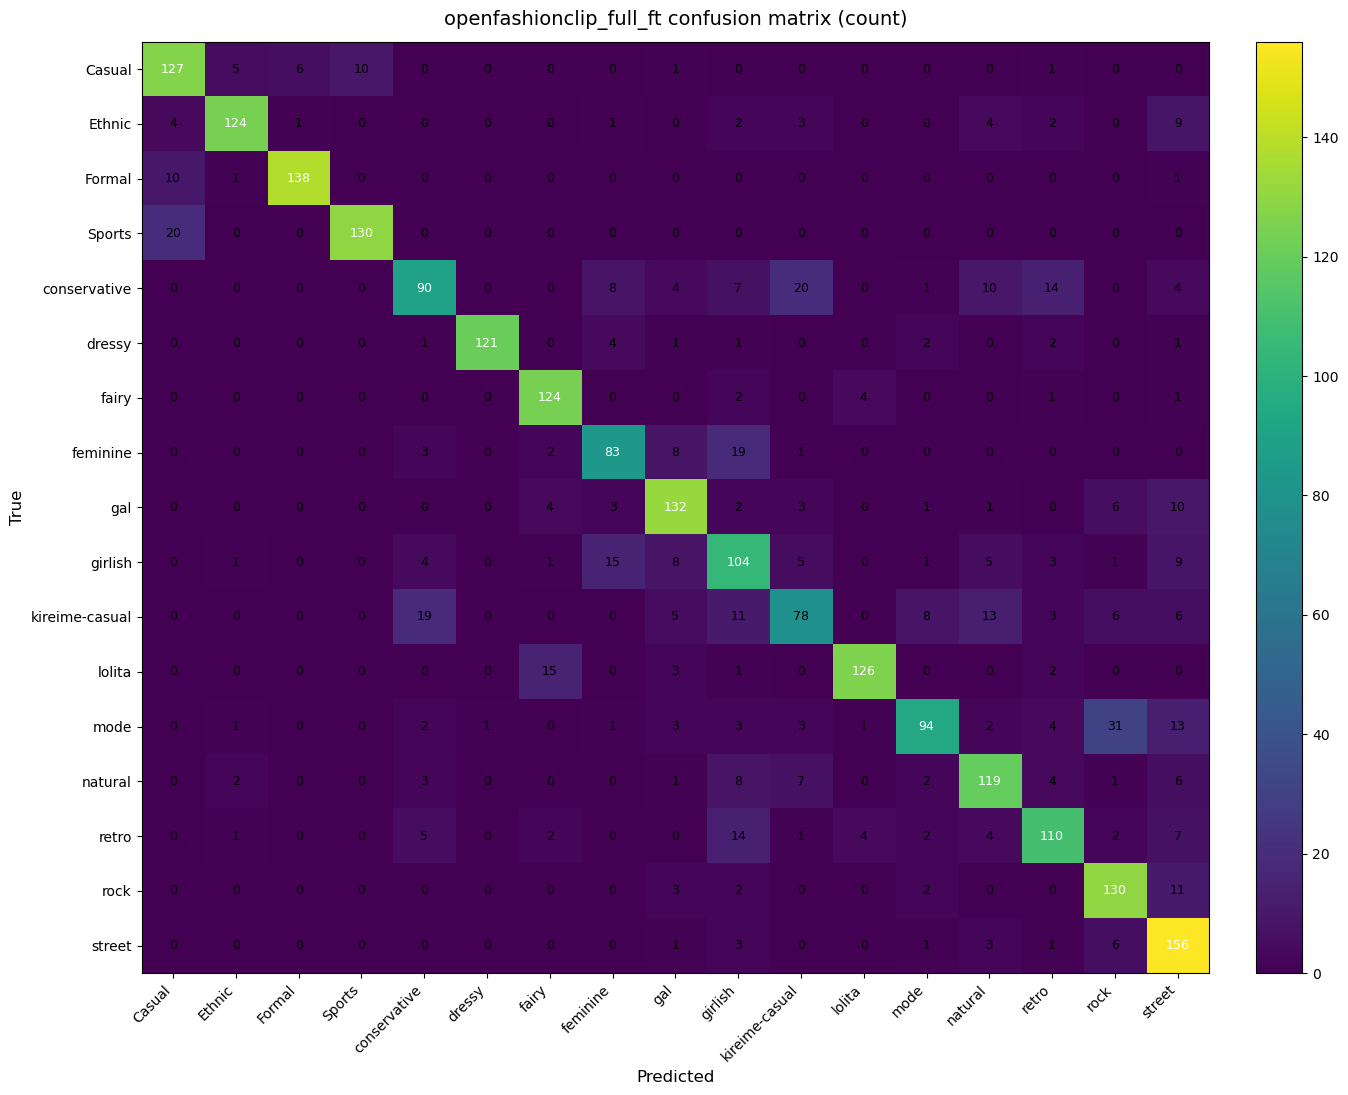

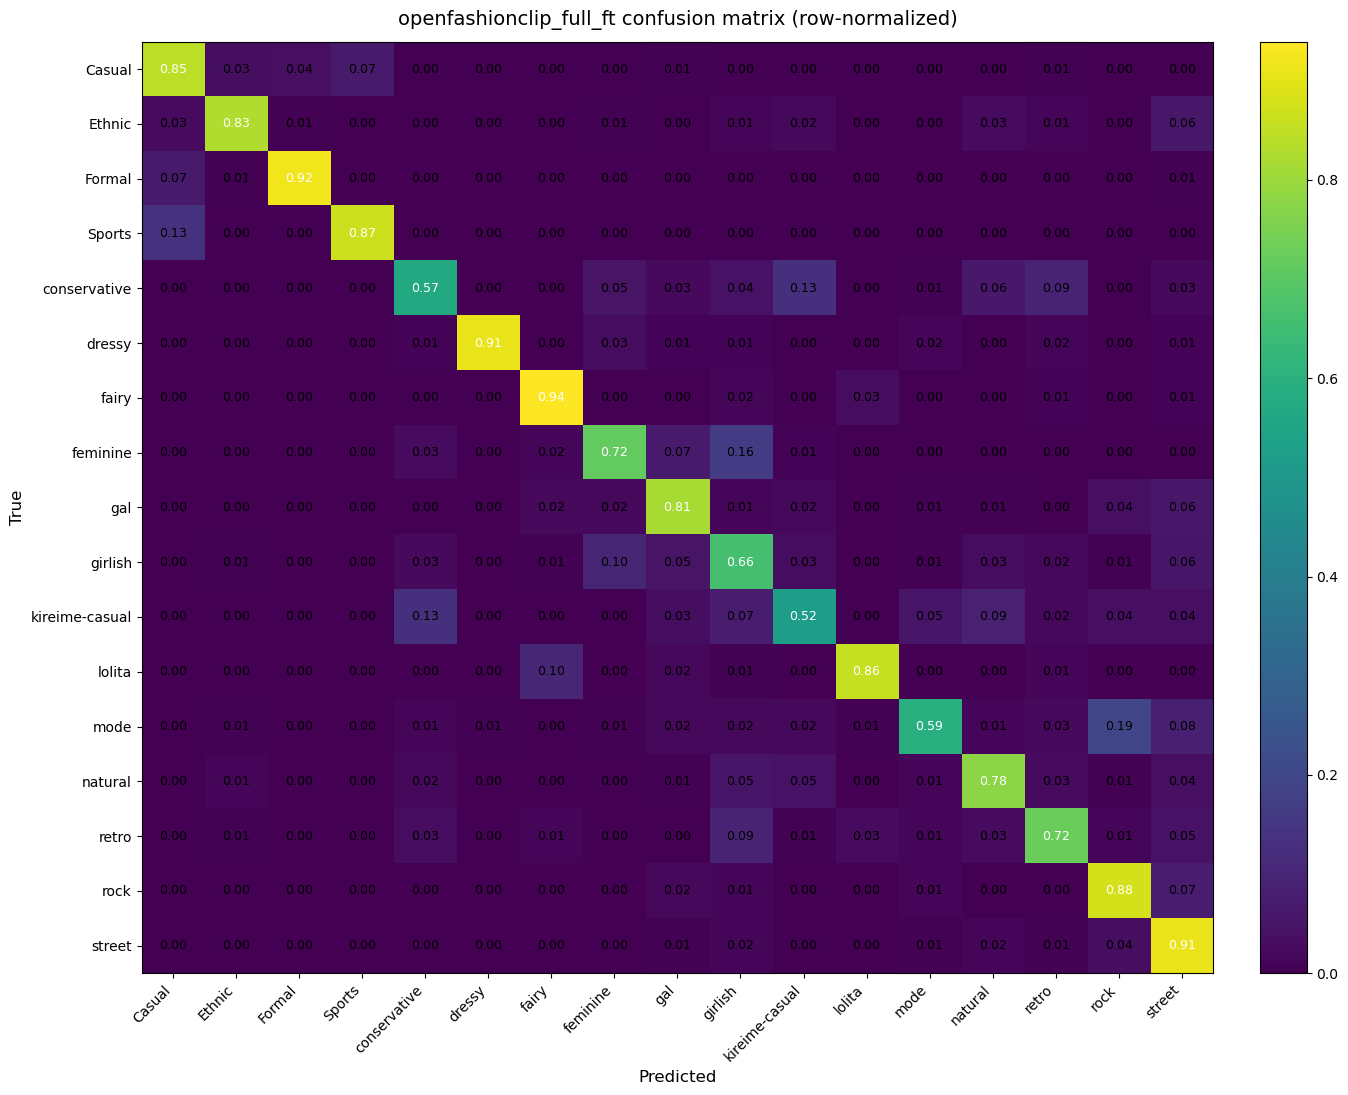


Loading predictions for: fashionclip_partial_ft
Path: ft_result\fashionclip_partial_ft\predictions\test_predictions.csv

fashionclip_partial_ft


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,fashionclip_partial_ft,"2,537",0.8613,0.8647,0.8611,0.8619


,label,precision,recall,f1,support
0,dressy,0.9635,0.9925,0.9778,133
1,lolita,0.9477,0.9864,0.9667,147
2,Ethnic,0.9589,0.9333,0.9459,150
3,Formal,0.9346,0.9533,0.9439,150
4,fairy,0.9603,0.9167,0.9380,132
5,Sports,0.9026,0.9267,0.9145,150
6,street,0.8966,0.9123,0.9043,171
7,gal,0.8974,0.8642,0.8805,162
8,rock,0.8618,0.8851,0.8733,148
9,natural,0.9185,0.8105,0.8611,153


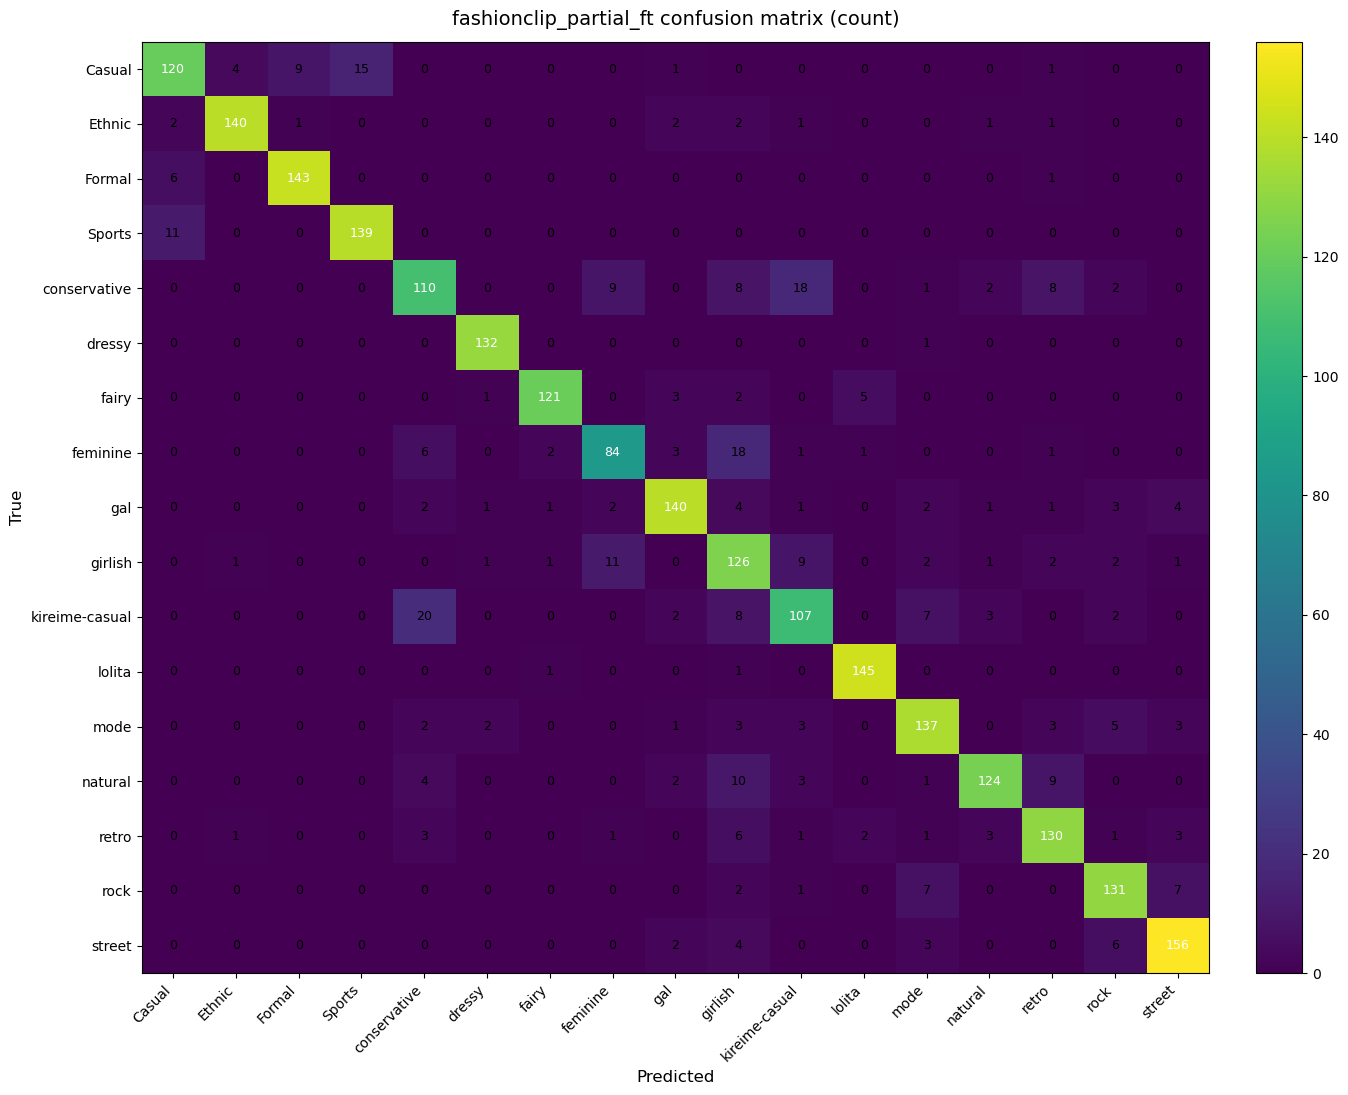

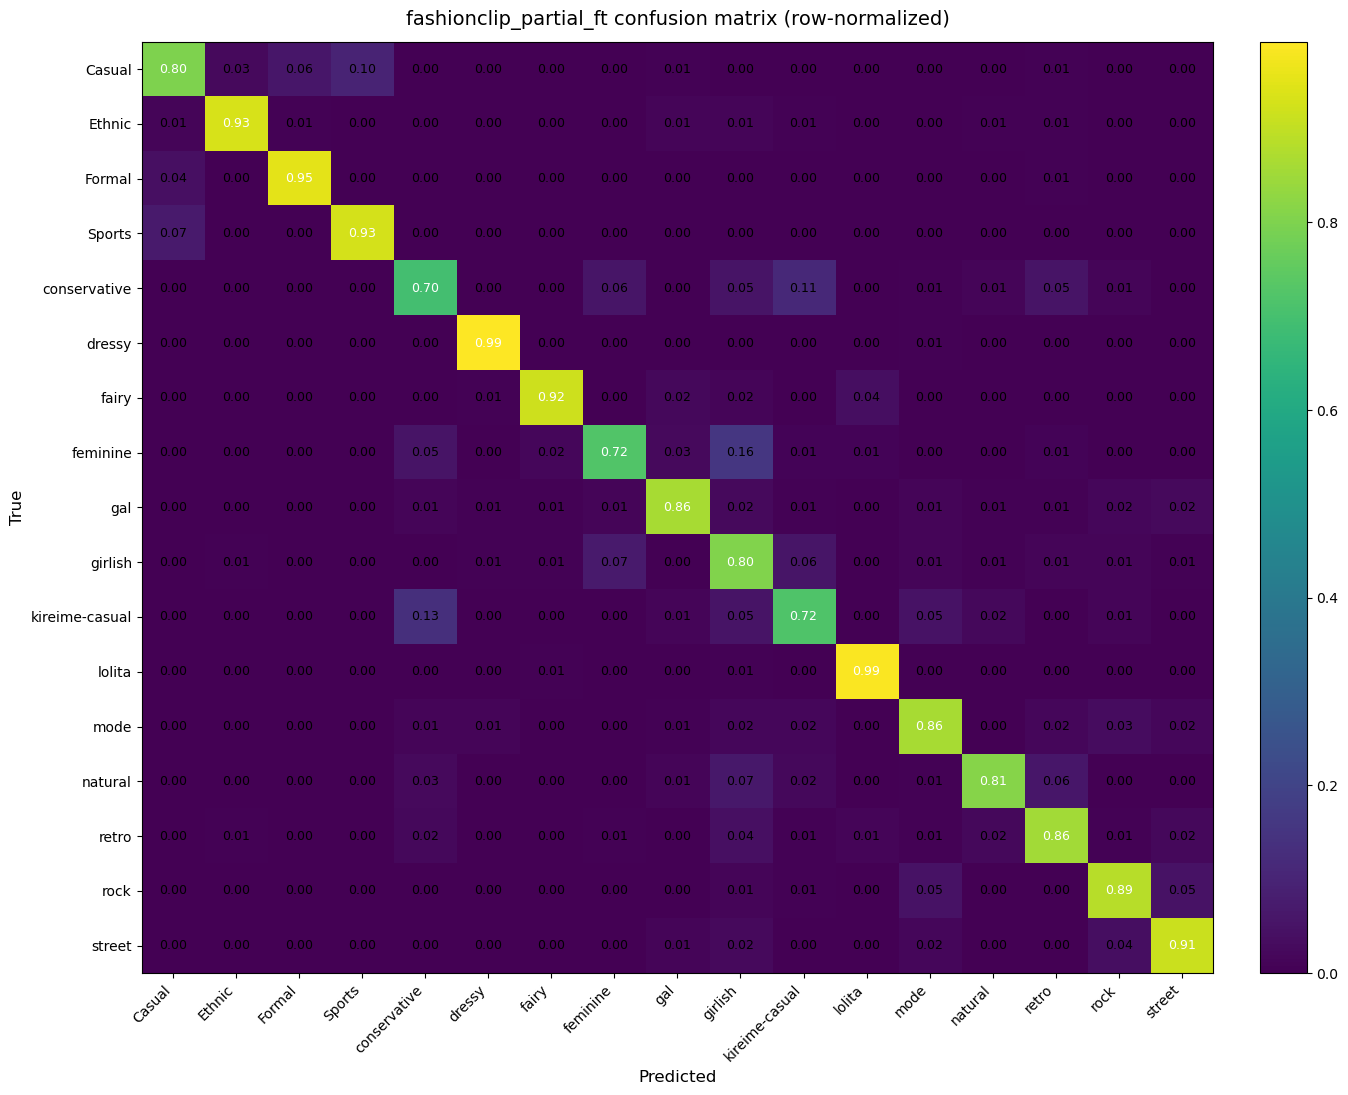


Loading predictions for: fashionclip_prompt
Path: ft_result\fashionclip_prompt\predictions\test_predictions.csv

fashionclip_prompt


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,fashionclip_prompt,"2,537",0.8534,0.8558,0.8550,0.8544


,label,precision,recall,f1,support
0,dressy,0.9704,0.9850,0.9776,133
1,lolita,0.9299,0.9932,0.9605,147
2,fairy,0.9612,0.9394,0.9502,132
3,Formal,0.9267,0.9267,0.9267,150
4,Ethnic,0.9320,0.9133,0.9226,150
5,Sports,0.8889,0.9067,0.8977,150
6,street,0.8909,0.8596,0.8750,171
7,rock,0.8333,0.9122,0.8710,148
8,mode,0.8070,0.8679,0.8364,159
9,gal,0.8571,0.8148,0.8354,162


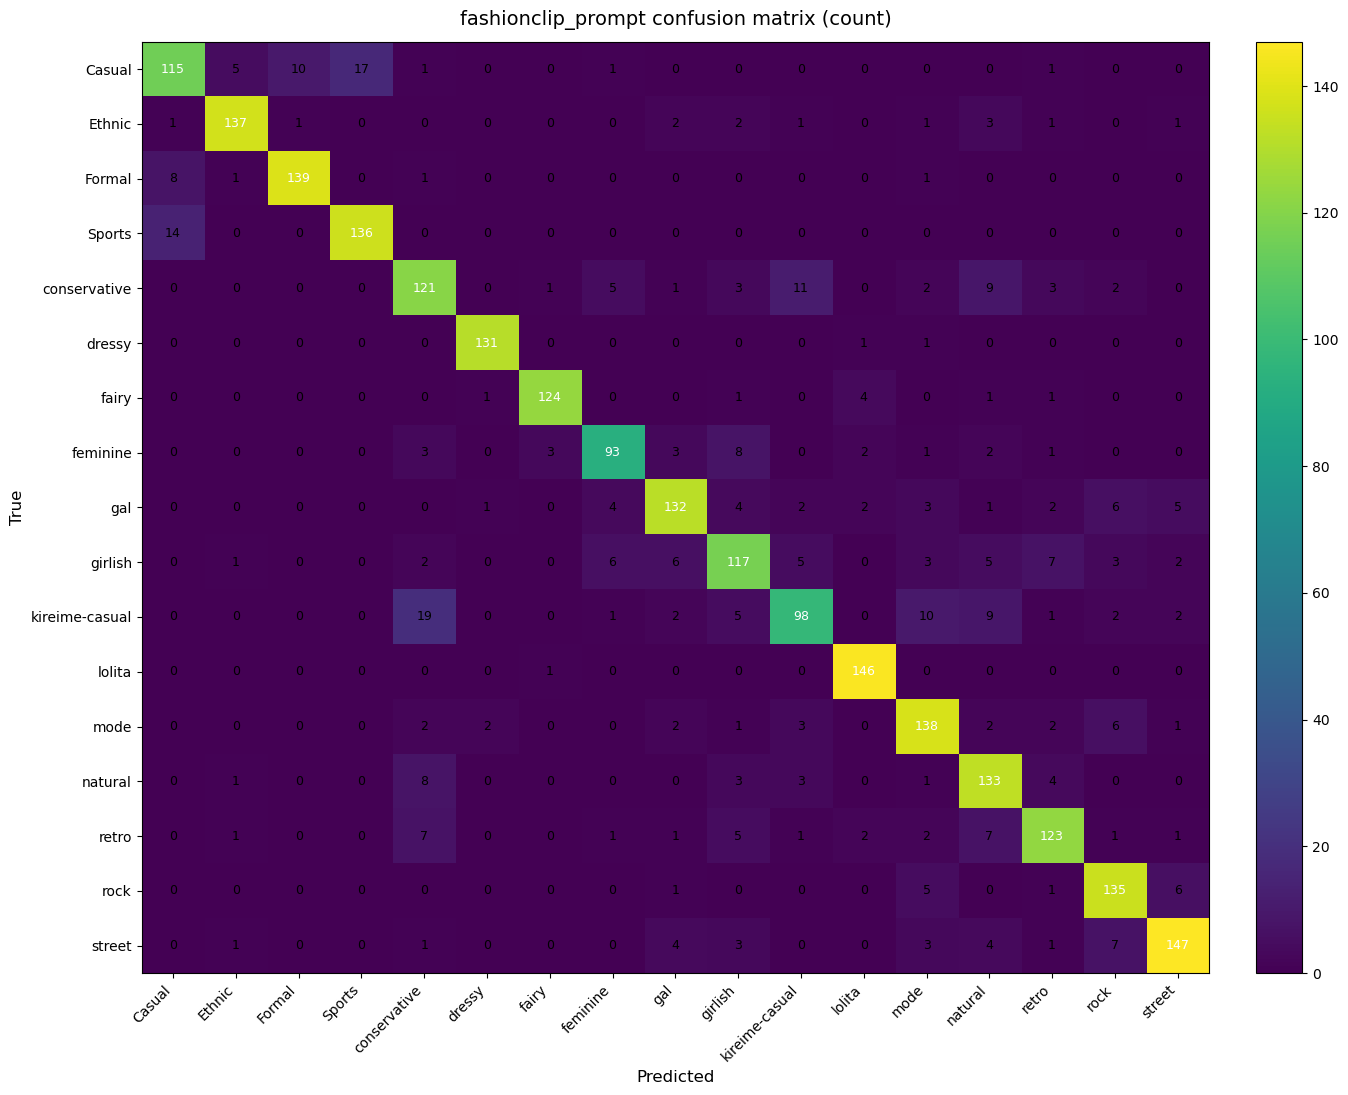

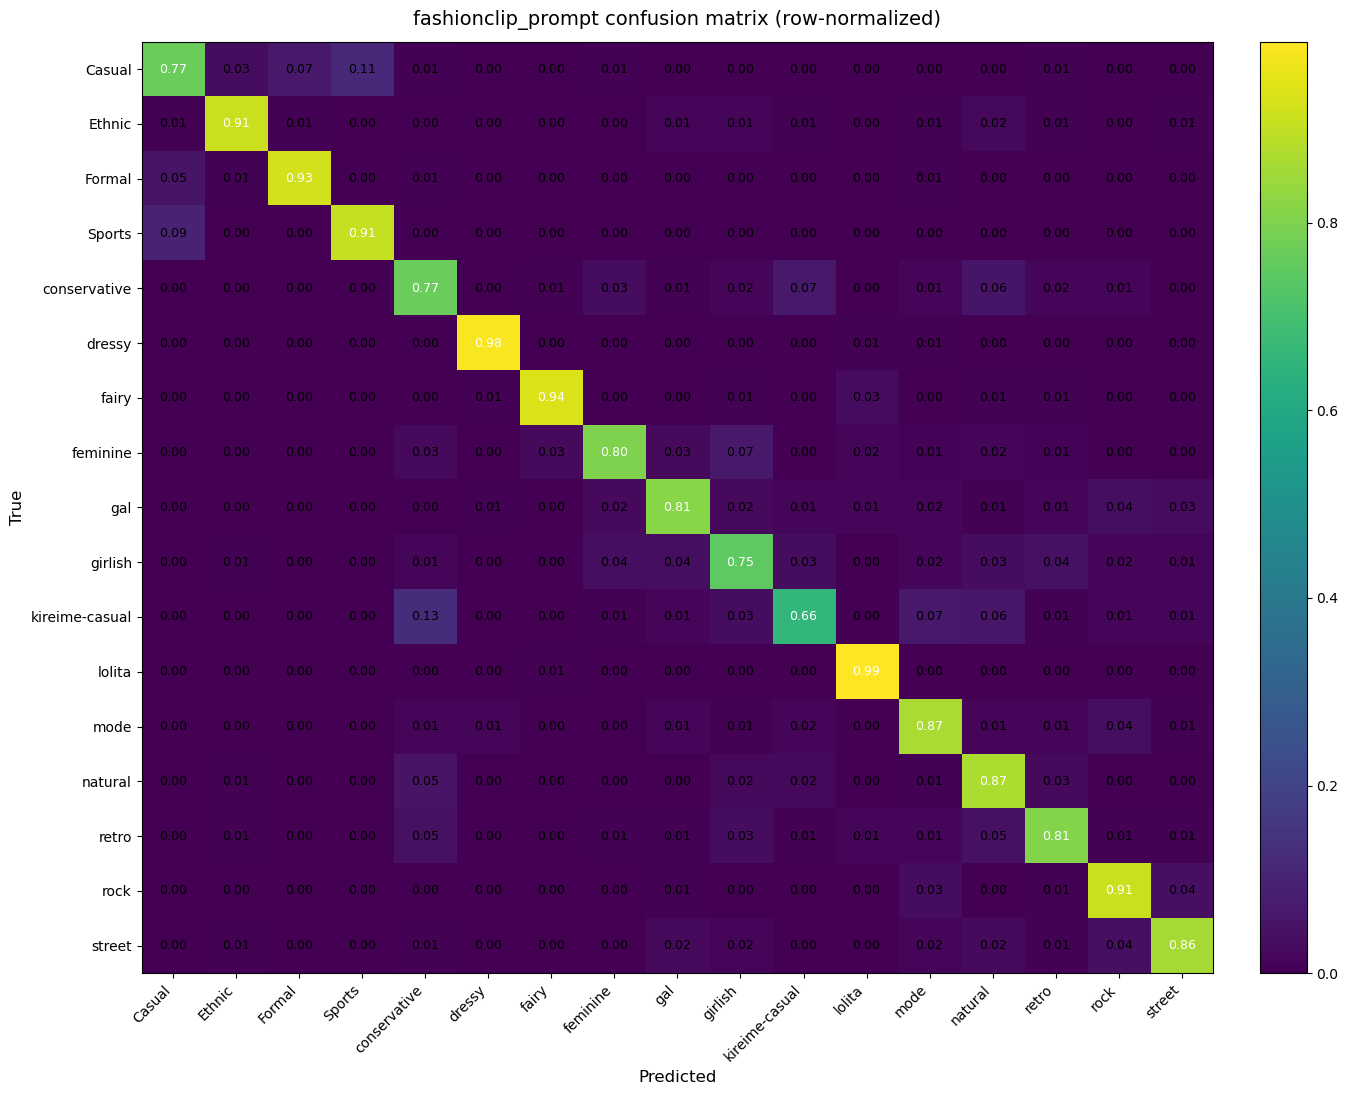


Loading predictions for: fashionclip_full_ft
Path: ft_result\fashionclip_full_ft\predictions\test_predictions.csv

fashionclip_full_ft


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,fashionclip_full_ft,"2,537",0.7856,0.7988,0.7882,0.7882


,label,precision,recall,f1,support
0,Formal,0.9267,0.9267,0.9267,150
1,dressy,0.8776,0.9699,0.9214,133
2,lolita,0.8797,0.9456,0.9115,147
3,Ethnic,0.9161,0.8733,0.8942,150
4,Sports,0.8933,0.8933,0.8933,150
5,fairy,0.9339,0.8561,0.8933,132
6,gal,0.9023,0.7407,0.8136,162
7,Casual,0.7959,0.7800,0.7879,150
8,rock,0.6768,0.9054,0.7746,148
9,retro,0.7468,0.7566,0.7516,152


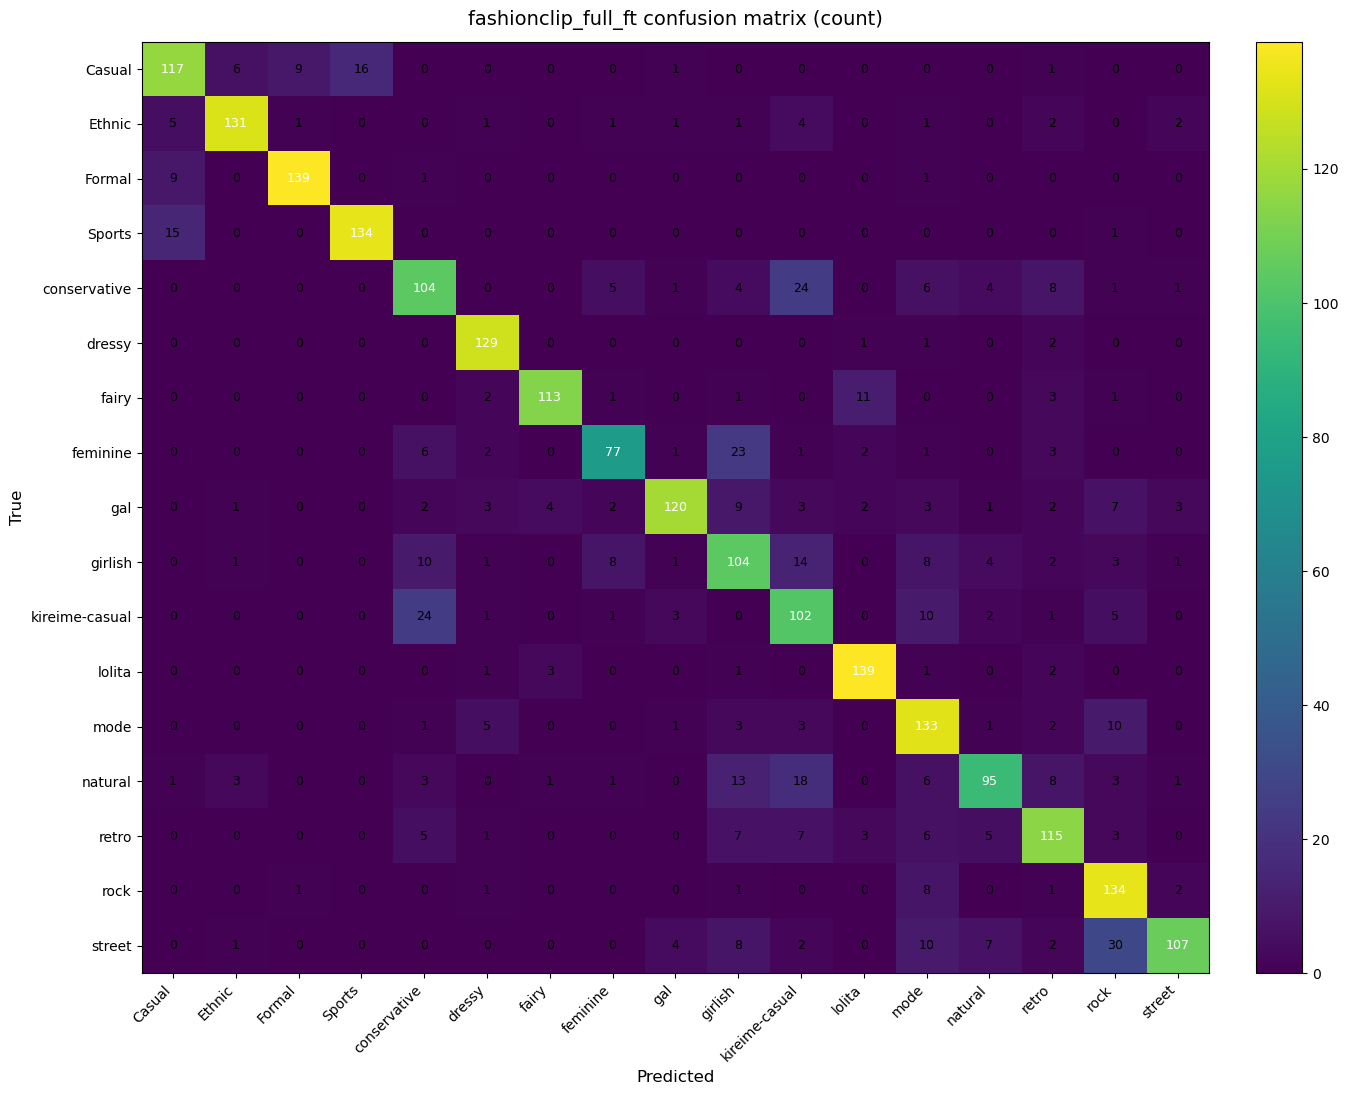

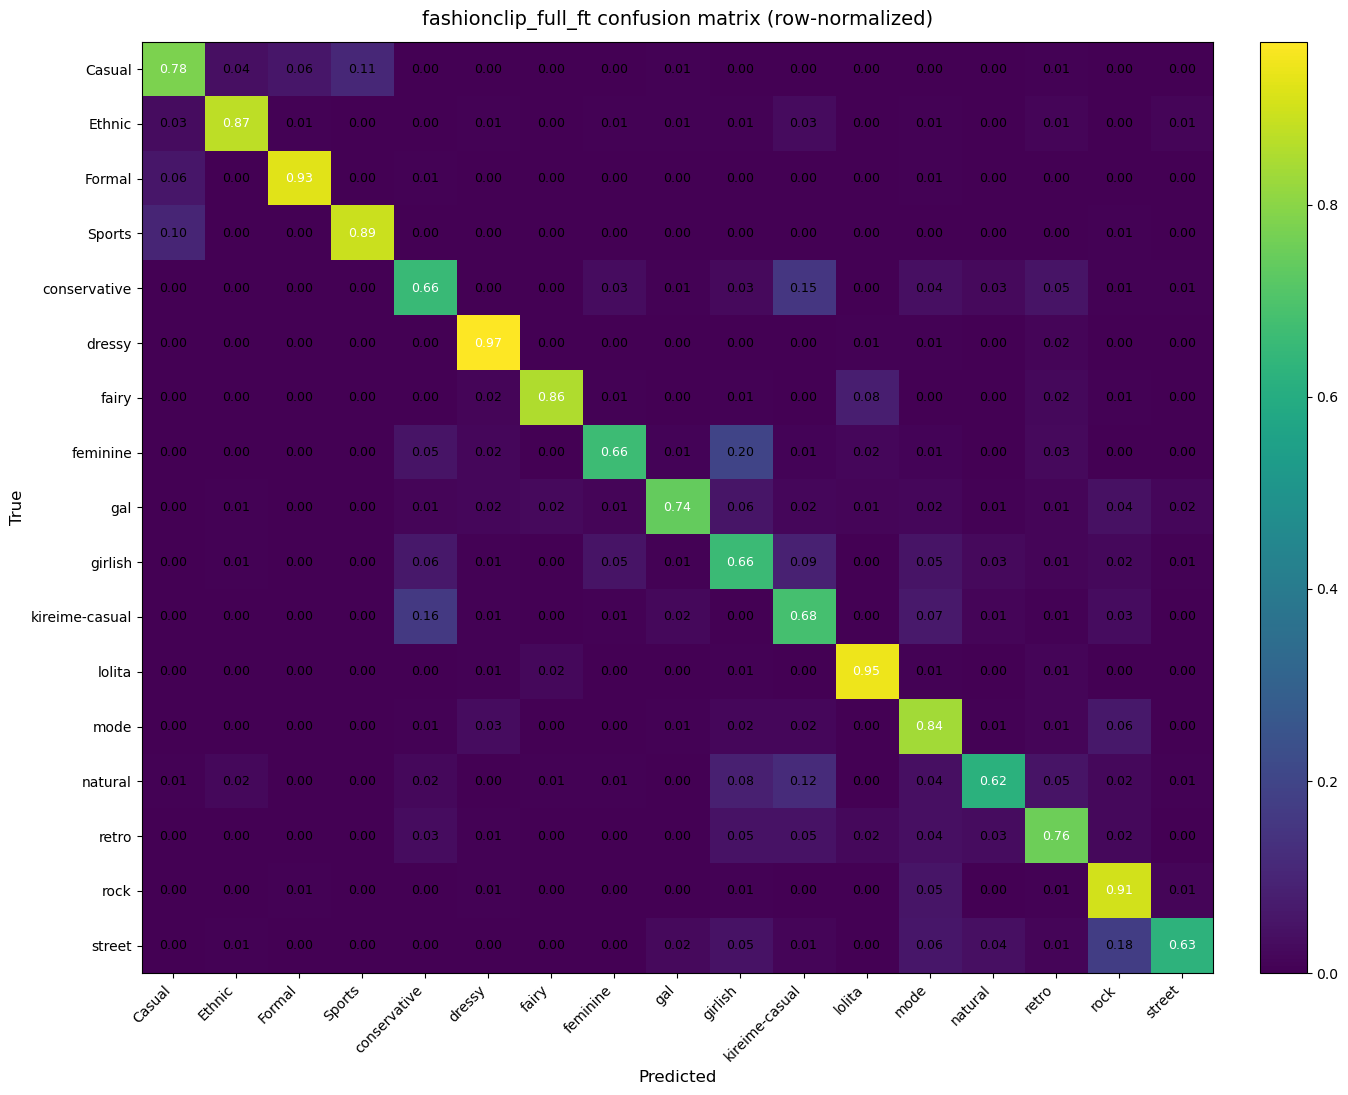


Loading predictions for: fashionclip_lora
Path: ft_result\fashionclip_lora\predictions\test_predictions.csv

fashionclip_lora


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,fashionclip_lora,"2,537",0.7343,0.7362,0.7378,0.7320


,label,precision,recall,f1,support
0,dressy,0.9149,0.9699,0.9416,133
1,Formal,0.9116,0.8933,0.9024,150
2,lolita,0.8208,0.9660,0.8875,147
3,fairy,0.8667,0.8864,0.8764,132
4,Ethnic,0.9071,0.8467,0.8759,150
5,Sports,0.7931,0.9200,0.8519,150
6,street,0.7030,0.8304,0.7614,171
7,rock,0.7619,0.7568,0.7593,148
8,mode,0.7877,0.7233,0.7541,159
9,Casual,0.7500,0.6400,0.6906,150


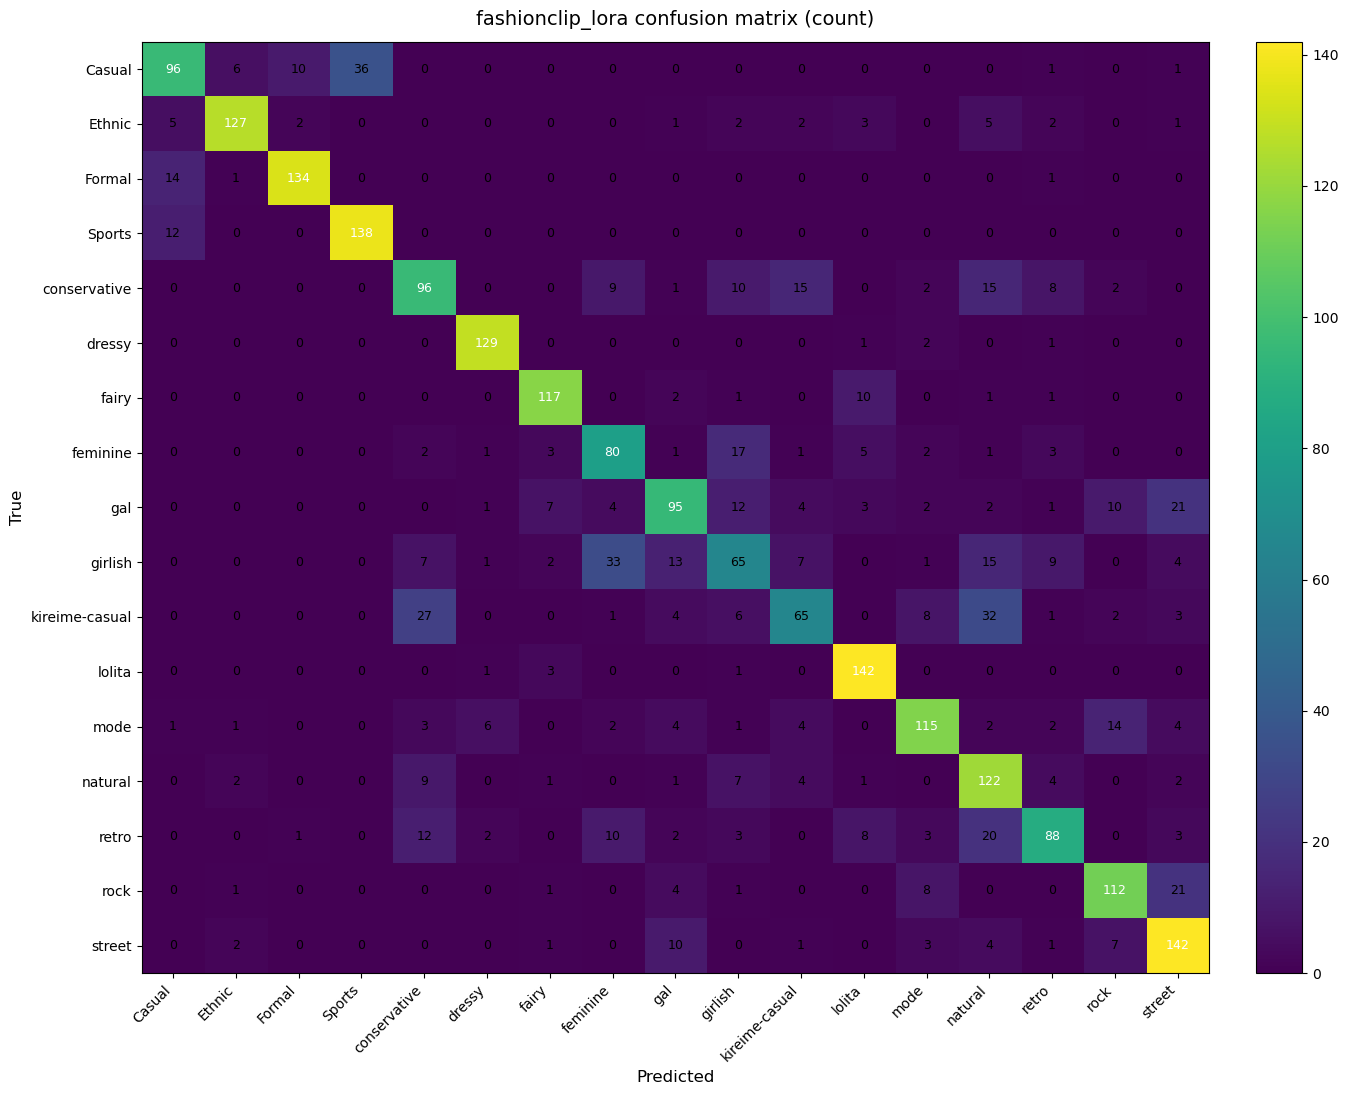

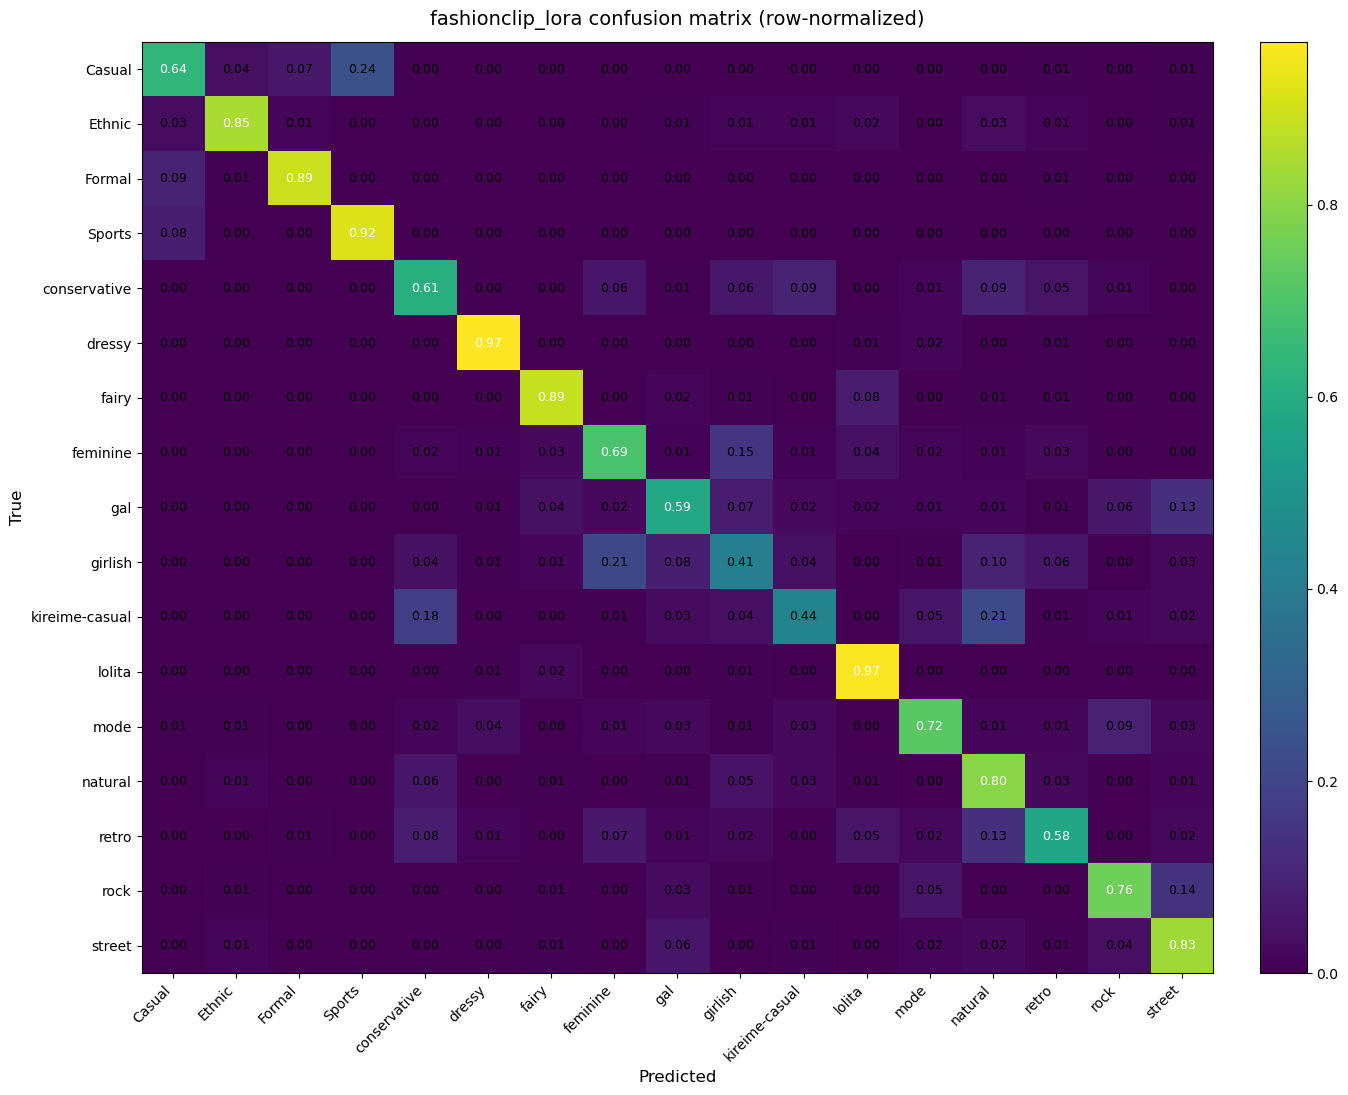


####################################################################################################
OVERALL COMPARISON
####################################################################################################


,experiment,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,openfashionclip_partial_ft,"2,537",0.8676,0.8716,0.8685,0.8687
1,openfashionclip_prompt,"2,537",0.8624,0.8655,0.8637,0.8640
2,fashionclip_partial_ft,"2,537",0.8613,0.8647,0.8611,0.8619
3,fashionclip_prompt,"2,537",0.8534,0.8558,0.8550,0.8544
4,fashionclip_full_ft,"2,537",0.7856,0.7988,0.7882,0.7882
5,openfashionclip_full_ft,"2,537",0.7828,0.7925,0.7844,0.7840
6,fashionclip_lora,"2,537",0.7343,0.7362,0.7378,0.7320


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
experiment_names = [
    "openfashionclip_partial_ft",
    "openfashionclip_prompt",
    "openfashionclip_full_ft",
    "fashionclip_partial_ft",
    "fashionclip_prompt",
    "fashionclip_full_ft",
    "fashionclip_lora"
]

FT_ROOT = "ft_result"
BASELINE_PRED_DIR = "baseline_results/predictions"

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
required_prediction_columns = ["id", "true_label", "pred_label"]

# ------------------------------------------------------------
# Display helpers
# ------------------------------------------------------------
def display_styled_table(df, caption):
    format_dict = {}
    for col in ["precision", "recall", "f1", "accuracy", "macro_precision", "macro_recall", "macro_f1"]:
        if col in df.columns:
            format_dict[col] = "{:.4f}"
    if "support" in df.columns:
        format_dict["support"] = "{:,.0f}"
    if "n_samples" in df.columns:
        format_dict["n_samples"] = "{:,.0f}"

    gradient_cols = [c for c in ["precision", "recall", "f1", "accuracy", "macro_precision", "macro_recall", "macro_f1"] if c in df.columns]

    styled = df.style.format(format_dict).set_caption(caption)
    if gradient_cols:
        styled = styled.background_gradient(subset=gradient_cols, cmap="YlGnBu")

    display(styled)

def annotate_confusion_matrix(ax, matrix, normalized=False):
    if normalized:
        threshold = 0.5
    else:
        threshold = matrix.max() * 0.5 if matrix.size > 0 else 0

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            text_color = "white" if value > threshold else "black"
            label = f"{value:.2f}" if normalized else f"{int(value)}"
            ax.text(
                col_idx,
                row_idx,
                label,
                ha="center",
                va="center",
                fontsize=9,
                color=text_color
            )

def plot_confusion_matrix(matrix, labels, title, normalize=False):
    if normalize:
        row_sums = np.maximum(matrix.sum(axis=1, keepdims=True), 1)
        matrix_to_plot = matrix.astype(float) / row_sums
    else:
        matrix_to_plot = matrix

    fig_width = max(8, len(labels) * 0.8)
    fig_height = max(6, len(labels) * 0.65)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(matrix_to_plot, aspect="auto")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=14, pad=12)

    annotate_confusion_matrix(ax, matrix_to_plot if normalize else matrix, normalized=normalize)

    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Core evaluation
# ------------------------------------------------------------
def evaluate_predictions(prediction_df, experiment_name):
    missing_columns = [col for col in required_prediction_columns if col not in prediction_df.columns]
    if missing_columns:
        raise ValueError(f"{experiment_name} is missing required columns: {missing_columns}")

    evaluation_df = prediction_df.copy()

    evaluation_df["true_label"] = evaluation_df["true_label"].astype(str)
    evaluation_df["pred_label"] = evaluation_df["pred_label"].astype(str)

    evaluation_df = evaluation_df.dropna(subset=["true_label", "pred_label"]).copy()

    if len(evaluation_df) == 0:
        print(f"Skipping {experiment_name}: no valid rows found")
        return None

    labels = sorted(evaluation_df["true_label"].unique().tolist())

    y_true = evaluation_df["true_label"].tolist()
    y_pred = evaluation_df["pred_label"].tolist()

    matrix = confusion_matrix(y_true, y_pred, labels=labels)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0
    )

    per_class_df = pd.DataFrame({
        "label": labels,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    }).sort_values(
        by=["f1", "recall", "precision"],
        ascending=False
    ).reset_index(drop=True)

    if "correct" in evaluation_df.columns:
        accuracy = evaluation_df["correct"].mean()
    else:
        accuracy = (evaluation_df["true_label"] == evaluation_df["pred_label"]).mean()

    summary_df = pd.DataFrame([{
        "experiment": experiment_name,
        "n_samples": len(evaluation_df),
        "accuracy": accuracy,
        "macro_precision": per_class_df["precision"].mean(),
        "macro_recall": per_class_df["recall"].mean(),
        "macro_f1": per_class_df["f1"].mean()
    }])

    print("\n" + "=" * 100)
    print(experiment_name)
    print("=" * 100)

    display_styled_table(summary_df, f"{experiment_name} summary")
    display_styled_table(per_class_df, f"{experiment_name} per-class metrics")

    plot_confusion_matrix(
        matrix,
        labels,
        f"{experiment_name} confusion matrix (count)",
        normalize=False
    )

    plot_confusion_matrix(
        matrix,
        labels,
        f"{experiment_name} confusion matrix (row-normalized)",
        normalize=True
    )

    return {
        "experiment": experiment_name,
        "n_samples": len(evaluation_df),
        "accuracy": accuracy,
        "macro_precision": per_class_df["precision"].mean(),
        "macro_recall": per_class_df["recall"].mean(),
        "macro_f1": per_class_df["f1"].mean()
    }

# ------------------------------------------------------------
# Collect prediction files
# ------------------------------------------------------------
prediction_sources = {}

baseline_files = {
    "FashionCLIP_baseline": os.path.join(BASELINE_PRED_DIR, "FashionCLIP_test_predictions.csv"),
    "OpenFashionCLIP_baseline": os.path.join(BASELINE_PRED_DIR, "OpenFashionCLIP_test_predictions.csv"),
    "ResNet50_baseline": os.path.join(BASELINE_PRED_DIR, "ResNet50_test_predictions.csv")
}

for model_name, file_path in baseline_files.items():
    if os.path.exists(file_path):
        prediction_sources[model_name] = file_path
    else:
        print(f"Missing baseline file: {file_path}")

for experiment_name in experiment_names:
    file_path = os.path.join(FT_ROOT, experiment_name, "predictions", "test_predictions.csv")
    if os.path.exists(file_path):
        prediction_sources[experiment_name] = file_path
    else:
        print(f"Missing fine-tuned file: {file_path}")

if len(prediction_sources) == 0:
    raise ValueError("No prediction files were found. Please check the paths.")

# ------------------------------------------------------------
# Run evaluation
# ------------------------------------------------------------
overall_results = []

for experiment_name, file_path in prediction_sources.items():
    print(f"\nLoading predictions for: {experiment_name}")
    print(f"Path: {file_path}")

    prediction_df = pd.read_csv(file_path)
    result = evaluate_predictions(prediction_df, experiment_name)

    if result is not None:
        overall_results.append(result)

# ------------------------------------------------------------
# Overall comparison
# ------------------------------------------------------------
if len(overall_results) > 0:
    overall_results_df = pd.DataFrame(overall_results).sort_values(
        by=["macro_f1", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "#" * 100)
    print("OVERALL COMPARISON")
    print("#" * 100)

    display_styled_table(overall_results_df, "Overall comparison across all experiments")